# Sesión conjunta · ¿Cuántas neuronas responden?
### L6 · viernes 18 de septiembre

Hoy calculamos, todos juntos, **la fracción de neuronas de su área que responden a las rejillas en
movimiento**. Es el único número que las once parejas van a calcular igual, y es el que vamos a
poner lado a lado el día de los pósters.

**Esto no es tarea.** Sale de esta sesión hecho. Pero debe incluirse en el notebook del proyecto final, y el resultado en el poster.

## Cómo se usa este notebook

Cada paso tiene dos celdas:

- Una **celda de texto con viñetas**: eso es lo que la celda de código tiene que hacer. Conviértanlo
  en un prompt, pídanle el código al modelo, péguenlo abajo y córranlo.
- Una **celda de código vacía**: ahí va lo que les devolvió, ya revisado.

Al final de cada paso hay una línea de **cómo saber si quedó bien**. Úsenla siempre. El modelo
escribe código que corre y da números equivocados sin avisar, y esa es la única defensa que tienen.

## Un consejo que les va a ahorrar tiempo

Cuando le pidan el código de los Pasos 2 en adelante, **péguenle primero la salida del paso 1**, la lista de variables del
archivo. Si el modelo no sabe cómo está hecho el archivo, se lo inventa: va a suponer nombres de
columnas que no existen y el código va a fallar o, peor, va a correr sobre lo que no es.

---
## Descargar los datos

Esta celda ya está escrita. Lo único que cambian es `MI_AREA`.

In [1]:
!pip install gdown -q
import numpy as np, gdown

# ---- Los ocho archivos. Cambien MI_AREA por la que les tocó en el sorteo. ----
IDS = {
    "VISp": "17-YMZMNfKXKYUK-vtPEPETfpUP0iHHut",    # 382 neuronas
    "VISl": "1GqceDf_3YPgPWAbDsIrjQySj4DRsd8Tw",    # 277 neuronas
    "VISal": "1TTyTRj92kbf7H6KE5-ah0DT7Ho2pV1pC",   # 481 neuronas
    "VISrl": "1n5XdMa5ZvRcKu7eTuI8latBQt5EHkLjJ",   # 308 neuronas
    "VISam": "1ODzh0cs3p_YE1FYwvET1qeRNxU1hqFbO",   # 368 neuronas
    "VISpm": "1kL7fnRaB5tYVrNoabMGTqJzHnz8GWl_z",   # 296 neuronas
    "LGd": "1ClWjSlBLWNbpVKKF3Kf5QpOwTtE0Wa2_",     # 301 neuronas
    "LP": "1P7GMFi7u4cy_3AApazkyuovTKf4IFou0",      # 431 neuronas
}

MI_AREA = "VISrl"        # <<<<<<<<<<  CAMBIEN ESTO.

gdown.download(id=IDS[MI_AREA], output="datos.npz", quiet=False)
d = np.load("datos.npz", allow_pickle=False)
print("\nÁrea:", MI_AREA, " ·  variables del archivo:")
print(d.files)

Downloading...
From: https://drive.google.com/uc?id=1n5XdMa5ZvRcKu7eTuI8latBQt5EHkLjJ
To: /content/datos.npz
100%|██████████| 21.4M/21.4M [00:00<00:00, 104MB/s]


Área: VISrl  ·  variables del archivo:
['area', 'fuente', 'filtro', 'u_id', 'u_raton', 'u_canal', 'u_profundidad', 'u_snr', 'u_amplitude_cutoff', 'u_presence_ratio', 'u_isi_violations', 'u_firing_rate', 'u_onda', 'e_clase', 'e_raton', 'e_t0', 'e_dur', 'e_orientacion', 'e_frec_temporal', 'e_frec_espacial', 'e_contraste', 'e_color', 'e_imagen', 's_unidad', 's_ensayo', 's_t']


---
## PASO 1 · Ver qué hay en el archivo

Lo que tiene que hacer la celda de abajo:

- Cuántas neuronas hay en total
- Cuántos ratones distintos (la columna u_raton)
- Cuántos ensayos hay de cada clase de estímulo (la columna e_clase)
- Cuántos PAs hay en total

> **Cómo saber si quedó bien.** El número de neuronas tiene que coincidir con el de la tabla del enunciado, y los ratones tienen que ser 5. Si no, están cargando el archivo equivocado.

In [2]:
import numpy as np

def resumen_archivo(d):
    """Resume el contenido del archivo .npz cargado en `d`."""
    # Neuronas: hay una entrada por neurona en las columnas u_*
    n_neuronas = len(d["u_id"])

    # Ratones distintos (columna u_raton)
    ratones = np.unique(d["u_raton"])
    n_ratones = len(ratones)

    # Ensayos por clase de estímulo (columna e_clase)
    clases, conteos = np.unique(d["e_clase"], return_counts=True)

    # Potenciales de acción: hay una entrada por PA en s_t
    n_pas = len(d["s_t"])

    print(f"Neuronas en total: {n_neuronas}")
    print(f"Ratones distintos: {n_ratones}  ->  {ratones}")
    print("Ensayos por clase de estímulo:")
    for c, n in zip(clases, conteos):
        print(f"   {c}: {n}")
    print(f"PAs en total: {n_pas:,}")

    return n_neuronas, n_ratones, dict(zip(clases, conteos)), n_pas

# Ejecutar
resumen = resumen_archivo(d)

Neuronas en total: 308
Ratones distintos: 5  ->  [715093703 750749662 756029989 761418226 798911424]
Ensayos por clase de estímulo:
   drifting_gratings: 2000
   flashes: 750
   natural_movie_one: 40
   natural_scenes: 2000
   spontaneous: 750
   static_gratings: 1250
PAs en total: 5,443,685


---
## PASO 2 · Separar los ensayos que nos interesan

Lo que tiene que hacer la celda de abajo:

- Los índices de los ensayos cuya clase es drifting_gratings, que son las rejillas en movimiento
- Los índices de los ensayos cuya clase es spontaneous, que es la pantalla gris sin estímulo
- Imprimir cuántos hay de cada uno

> **Cómo saber si quedó bien.** Deben salir unos 2000 ensayos de rejillas y unos 750 de espontáneo, que son 400 y 150 por cada uno de los 5 ratones.

In [3]:
import numpy as np

def separar_ensayos(d):
    """Devuelve los índices de los ensayos de rejillas en movimiento y de espontáneo."""
    # Índices (posiciones en las tablas e_*) de cada clase de estímulo
    idx_rejillas = np.where(d["e_clase"] == "drifting_gratings")[0]
    idx_espont   = np.where(d["e_clase"] == "spontaneous")[0]

    print(f"Ensayos de rejillas en movimiento (drifting_gratings): {len(idx_rejillas)}")
    print(f"Ensayos espontáneos (spontaneous): {len(idx_espont)}")

    # Comprobación extra: ensayos por ratón en cada grupo
    for nombre, idx in [("rejillas", idx_rejillas), ("espontáneo", idx_espont)]:
        ratones, conteos = np.unique(d["e_raton"][idx], return_counts=True)
        print(f"  {nombre} por ratón: {dict(zip(ratones, conteos))}")

    return idx_rejillas, idx_espont

# Ejecutar
idx_rejillas, idx_espont = separar_ensayos(d)

#idea 2

import numpy as np

def separar_ensayos(d):
    """Devuelve los índices de los ensayos de rejillas en movimiento y de espontáneo."""
    idx_rejillas = np.where(d["e_clase"] == "drifting_gratings")[0]
    idx_espont   = np.where(d["e_clase"] == "spontaneous")[0]

    print(f"Ensayos de rejillas en movimiento (drifting_gratings): {len(idx_rejillas)}")
    print(f"Ensayos espontáneos (spontaneous): {len(idx_espont)}")

    # Comprobación extra: ensayos por ratón en cada grupo
    for nombre, idx in [("rejillas", idx_rejillas), ("espontáneo", idx_espont)]:
        ratones, conteos = np.unique(d["e_raton"][idx], return_counts=True)
        print(f"  {nombre} por ratón: { {int(r): int(n) for r, n in zip(ratones, conteos)} }")

    return idx_rejillas, idx_espont

# Ejecutar
idx_rejillas, idx_espont = separar_ensayos(d)

Ensayos de rejillas en movimiento (drifting_gratings): 2000
Ensayos espontáneos (spontaneous): 750
  rejillas por ratón: {np.int64(715093703): np.int64(400), np.int64(750749662): np.int64(400), np.int64(756029989): np.int64(400), np.int64(761418226): np.int64(400), np.int64(798911424): np.int64(400)}
  espontáneo por ratón: {np.int64(715093703): np.int64(150), np.int64(750749662): np.int64(150), np.int64(756029989): np.int64(150), np.int64(761418226): np.int64(150), np.int64(798911424): np.int64(150)}
Ensayos de rejillas en movimiento (drifting_gratings): 2000
Ensayos espontáneos (spontaneous): 750
  rejillas por ratón: {715093703: 400, 750749662: 400, 756029989: 400, 761418226: 400, 798911424: 400}
  espontáneo por ratón: {715093703: 150, 750749662: 150, 756029989: 150, 761418226: 150, 798911424: 150}


---
## PASO 3 · La tasa de disparo de cada neurona en cada ensayo

Lo que tiene que hacer la celda de abajo:

- Para cada neurona y cada ensayo de rejilla, contar los PAs que caen entre 0 y 2 segundos y dividir por 2. Eso es la tasa evocada, en hercios
- Hacer lo mismo con los ensayos de espontáneo, también entre 0 y 2 segundos. Esa es la tasa basal
- Guardar las dos como matrices con una fila por neurona y una columna por ensayo
- Importante para el prompt: s_unidad dice a qué neurona pertenece cada PA y s_ensayo a qué ensayo, y los dos son ÍNDICES de las tablas u_ y e_, no identificadores
- Y esto también, o el resultado sale mal sin avisar: la tabla de ensayos trae los CINCO RATONES JUNTOS, y cada neurona solo vio los ensayos de SU ratón. Hay que emparejar u_raton con e_raton y quedarse, para cada neurona, solo con sus propias columnas

> **Cómo saber si quedó bien.** La tasa evocada mediana tiene que estar entre 1 y 30 Hz. Si les da 0, casi seguro no emparejaron los ratones: están promediando cada neurona sobre 2000 ensayos cuando solo vio 400, y los otros 1600 son ceros que no significan nada.

In [4]:
import numpy as np

def calcular_tasas(d, idx_rejillas, idx_espont, ventana=2.0):
    """Tasa evocada (rejillas) y basal (espontáneo) por neurona y ensayo, en Hz.
    Devuelve matrices (neuronas x ensayos) con NaN en los ensayos de otros ratones,
    y las máscaras booleanas de los ensayos válidos de cada neurona."""
    n_neu = len(d["u_id"])
    n_ens = len(d["e_clase"])

    s_unidad = d["s_unidad"].astype(np.int64)   # índice en las tablas u_
    s_ensayo = d["s_ensayo"].astype(np.int64)   # índice en las tablas e_
    s_t      = d["s_t"]

    # Comprobaciones de que los índices son válidos
    assert s_unidad.min() >= 0 and s_unidad.max() < n_neu, "s_unidad fuera de rango"
    assert s_ensayo.min() >= 0 and s_ensayo.max() < n_ens, "s_ensayo fuera de rango"
    print(f"Rango de s_t: {s_t.min():.3f} a {s_t.max():.3f} s")

    # Solo los PAs entre 0 y 2 s
    en_ventana = (s_t >= 0) & (s_t < ventana)

    # Conteo de PAs por (neurona, ensayo) para TODOS los ensayos de una vez
    llave = s_unidad[en_ventana] * n_ens + s_ensayo[en_ventana]
    conteos = np.bincount(llave, minlength=n_neu * n_ens).reshape(n_neu, n_ens)
    tasas = conteos / ventana                    # Hz

    # Emparejar ratones: cada neurona solo con los ensayos de SU ratón
    u_raton, e_raton = d["u_raton"], d["e_raton"]
    valido_evo = (u_raton[:, None] == e_raton[idx_rejillas][None, :])   # neuronas x rejillas
    valido_bas = (u_raton[:, None] == e_raton[idx_espont][None, :])     # neuronas x espontáneo

    tasa_evocada = np.where(valido_evo, tasas[:, idx_rejillas], np.nan)
    tasa_basal   = np.where(valido_bas, tasas[:, idx_espont],   np.nan)

    # Resumen y comprobaciones
    print(f"Matriz evocada: {tasa_evocada.shape}  |  matriz basal: {tasa_basal.shape}")
    print(f"Ensayos válidos por neurona (evocada): {np.unique(valido_evo.sum(axis=1))}")
    print(f"Ensayos válidos por neurona (basal):   {np.unique(valido_bas.sum(axis=1))}")
    med = np.nanmedian(np.nanmean(tasa_evocada, axis=1))
    print(f"Mediana de la tasa evocada promedio: {med:.2f} Hz")

    return tasa_evocada, tasa_basal, valido_evo, valido_bas

# Ejecutar
tasa_evocada, tasa_basal, valido_evo, valido_bas = calcular_tasas(d, idx_rejillas, idx_espont)

med_basal = np.nanmedian(np.nanmean(tasa_basal, axis=1))
print(f"Mediana de la tasa basal promedio: {med_basal:.2f} Hz")

#verson completa

import numpy as np
import pandas as pd

def cargar_tablas(d):
    """Devuelve tres DataFrames: neuronas (u_), ensayos (e_) y PAs (s_)."""
    tablas = {}
    for prefijo, nombre in [("u_", "neuronas"), ("e_", "ensayos"), ("s_", "pas")]:
        claves = [k for k in d.files if k.startswith(prefijo)]
        n = len(d[claves[0]])
        cols, omitidas = {}, []
        for k in claves:
            arr = d[k]
            if arr.ndim == 1 and len(arr) == n:
                cols[k] = arr
            else:
                omitidas.append((k, arr.shape))   # p. ej. formas de onda 2D
        df = pd.DataFrame(cols)
        tablas[nombre] = df
        print(f"\n=== Tabla de {nombre} ({prefijo}*): {df.shape[0]:,} filas x {df.shape[1]} columnas ===")
        if omitidas:
            print("Columnas no incluidas por no ser 1D:", omitidas)
        print(df.head())
    print("\nMetadatos del archivo:", {k: d[k] for k in ["area", "fuente", "filtro"] if k in d.files})
    return tablas["neuronas"], tablas["ensayos"], tablas["pas"]

# Ejecutar
neuronas, ensayos, pas = cargar_tablas(d)

#paso 3

print(neuronas["u_snr"].min(), neuronas["u_presence_ratio"].min())

fila = pas.iloc[0]
neurona = neuronas.iloc[int(fila["s_unidad"])]   # quién disparó
ensayo  = ensayos.iloc[int(fila["s_ensayo"])]    # en qué ensayo
print("Neurona:", neurona["u_id"], "· ratón:", neurona["u_raton"])
print("Ensayo :", ensayo["e_clase"], "· ratón:", ensayo["e_raton"])
print("Tiempo :", fila["s_t"], "s desde el inicio del ensayo")



Rango de s_t: -1.000 a 31.025 s
Matriz evocada: (308, 2000)  |  matriz basal: (308, 750)
Ensayos válidos por neurona (evocada): [400]
Ensayos válidos por neurona (basal):   [150]
Mediana de la tasa evocada promedio: 3.72 Hz
Mediana de la tasa basal promedio: 3.29 Hz

=== Tabla de neuronas (u_*): 308 filas x 9 columnas ===
Columnas no incluidas por no ser 1D: [('u_onda', (308, 7, 82))]
        u_id    u_raton    u_canal  u_profundidad     u_snr  \
0  951890129  761418226  850080796         1960.0  4.018585   
1  951890141  761418226  850080800         1980.0  3.093800   
2  951890199  761418226  850080818         2080.0  1.115762   
3  951890238  761418226  850080824         2100.0  5.503520   
4  951890265  761418226  850080828         2120.0  3.098553   

   u_amplitude_cutoff  u_presence_ratio  u_isi_violations  u_firing_rate  
0            0.000361              0.99          0.014733      44.947036  
1            0.000139              0.99          0.000396       9.593012  
2       

In [5]:
import numpy as np
import pandas as pd

try:
    from IPython.display import display, Markdown
    _HAY_IPYTHON = True
except ImportError:
    _HAY_IPYTHON = False

# Descripción de cada columna (se usa solo si la columna existe en el archivo)
DESC = {
    "u_id": "Identificador único de la neurona (es un nombre, no una posición)",
    "u_raton": "Ratón del que viene la neurona",
    "u_canal": "Canal del electrodo donde se registró",
    "u_profundidad": "Profundidad del registro",
    "u_snr": "Relación señal-ruido (más alto = mejor)",
    "u_amplitude_cutoff": "Fracción estimada de espigas perdidas (más bajo = mejor)",
    "u_presence_ratio": "Fracción de la sesión en que la neurona estuvo presente (más cerca de 1 = mejor)",
    "u_isi_violations": "Espigas demasiado seguidas, posible contaminación (más bajo = mejor)",
    "u_firing_rate": "Tasa de disparo promedio de toda la sesión (Hz)",
    "e_clase": "Tipo de estímulo",
    "e_raton": "Ratón al que se le presentó el ensayo",
    "e_t0": "Inicio del ensayo, en segundos desde el comienzo de la sesión",
    "e_dur": "Duración del ensayo (s)",
    "e_orientacion": "Dirección de la rejilla (grados)",
    "e_frec_temporal": "Velocidad de la rejilla (Hz)",
    "e_frec_espacial": "Finura de las barras de la rejilla",
    "e_contraste": "Contraste del estímulo",
    "e_color": "Color del estímulo (NaN si no aplica)",
    "e_imagen": "Imagen mostrada (NaN si no aplica)",
    "s_unidad": "POSICIÓN (fila) de la neurona en la tabla neuronas",
    "s_ensayo": "POSICIÓN (fila) del ensayo en la tabla ensayos",
    "s_t": "Instante del PA (s), relativo al inicio de su ensayo",
}


def _fmt(x):
    """Formatea un valor para una celda de tabla Markdown."""
    if isinstance(x, (float, np.floating)):
        return "NaN" if np.isnan(x) else f"{x:.4g}"
    return str(x)


def _tabla_md(df):
    """Convierte un DataFrame en una tabla Markdown (sin depender de tabulate)."""
    cab = "| " + " | ".join(df.columns) + " |"
    sep = "|" + "|".join(["---"] * len(df.columns)) + "|"
    filas = ["| " + " | ".join(_fmt(v) for v in fila) + " |" for fila in df.itertuples(index=False)]
    return "\n".join([cab, sep] + filas)


def _describir_columnas(df):
    lineas = ["| Columna | Significado |", "|---|---|"]
    for c in df.columns:
        lineas.append(f"| `{c}` | {DESC.get(c, '(sin descripción)')} |")
    return "\n".join(lineas)


def cargar_tablas(d, n_filas=5):
    """Arma las tres tablas del archivo (neuronas, ensayos, PAs) y las imprime en Markdown.
    Devuelve tres DataFrames: neuronas, ensayos, pas."""
    tablas, omitidas_por_tabla = {}, {}
    for prefijo, nombre in [("u_", "neuronas"), ("e_", "ensayos"), ("s_", "pas")]:
        claves = [k for k in d.files if k.startswith(prefijo)]
        n = len(d[claves[0]])
        cols, omitidas = {}, []
        for k in claves:
            arr = d[k]
            if arr.ndim == 1 and len(arr) == n:
                cols[k] = arr
            else:
                omitidas.append((k, arr.shape))
        tablas[nombre] = pd.DataFrame(cols)
        omitidas_por_tabla[nombre] = omitidas

    neuronas, ensayos, pas = tablas["neuronas"], tablas["ensayos"], tablas["pas"]

    md = []

    # ---------- Encabezado ----------
    md.append(f"# Las tres tablas del archivo · área {d['area']}")
    md.append(f"**Fuente:** {d['fuente']}")
    md.append(f"**Filtro de calidad:** `{d['filtro']}`")
    md.append(
        "| Tabla | Una fila representa | Filas | Columnas |\n|---|---|---|---|\n"
        f"| `neuronas` (`u_`) | una neurona | {len(neuronas):,} | {neuronas.shape[1]} |\n"
        f"| `ensayos` (`e_`) | una presentación de estímulo | {len(ensayos):,} | {ensayos.shape[1]} |\n"
        f"| `pas` (`s_`) | un potencial de acción | {len(pas):,} | {pas.shape[1]} |"
    )

    # ---------- Tabla neuronas ----------
    md.append("---\n## 1. Tabla `neuronas` (`u_*`)")
    md.append("Catálogo de neuronas: quién es cada una, de qué ratón viene y qué tan buena es su calidad de registro. "
              "No contiene actividad.")
    md.append(f"**Tamaño:** {neuronas.shape[0]:,} filas × {neuronas.shape[1]} columnas · "
              f"**Ratones distintos:** {neuronas['u_raton'].nunique()}")
    if omitidas_por_tabla["neuronas"]:
        md.append("**Columnas que no entran en la tabla plana (no son 1D):** " +
                  ", ".join(f"`{k}` con forma {s}" for k, s in omitidas_por_tabla["neuronas"]))
    md.append(_describir_columnas(neuronas))
    md.append(f"**Primeras {n_filas} filas:**\n\n" + _tabla_md(neuronas.head(n_filas)))
    md.append("**Neuronas por ratón:**\n\n" +
              _tabla_md(neuronas["u_raton"].value_counts().rename_axis("u_raton").reset_index(name="neuronas")))

    # ---------- Tabla ensayos ----------
    md.append("---\n## 2. Tabla `ensayos` (`e_*`)")
    md.append("Registro de todo lo que se mostró en la pantalla. Cada fila es un ensayo. "
              "Trae los ensayos de **todos los ratones mezclados**.")
    md.append(f"**Tamaño:** {ensayos.shape[0]:,} filas × {ensayos.shape[1]} columnas")
    md.append(_describir_columnas(ensayos))
    md.append(f"**Primeras {n_filas} filas:**\n\n" + _tabla_md(ensayos.head(n_filas)))
    md.append("**Ensayos por clase de estímulo:**\n\n" +
              _tabla_md(ensayos["e_clase"].value_counts().rename_axis("e_clase").reset_index(name="ensayos")))
    por_raton = ensayos.groupby(["e_raton", "e_clase"]).size().unstack(fill_value=0).reset_index()
    md.append("**Ensayos por ratón y clase:**\n\n" + _tabla_md(por_raton))

    # ---------- Tabla pas ----------
    md.append("---\n## 3. Tabla `pas` (`s_*`)")
    md.append("La actividad real: una fila por cada potencial de acción (PA). "
              "`s_unidad` y `s_ensayo` son **posiciones** en las otras dos tablas, no identificadores.")
    md.append(f"**Tamaño:** {pas.shape[0]:,} filas × {pas.shape[1]} columnas · "
              f"**Rango de `s_t`:** {pas['s_t'].min():.3f} a {pas['s_t'].max():.3f} s")
    md.append(_describir_columnas(pas))
    md.append(f"**Primeras {n_filas} filas:**\n\n" + _tabla_md(pas.head(n_filas)))

    # ---------- Cómo se conectan ----------
    f0 = pas.iloc[0]
    neu0 = neuronas.iloc[int(f0["s_unidad"])]
    ens0 = ensayos.iloc[int(f0["s_ensayo"])]
    coincide = "sí" if neu0["u_raton"] == ens0["e_raton"] else "NO (revisar)"
    md.append("---\n## 4. Cómo se conectan")
    md.append(
        "- `pas.s_unidad` → fila de `neuronas`\n"
        "- `pas.s_ensayo` → fila de `ensayos`\n"
        "- `neuronas.u_raton` debe coincidir con `ensayos.e_raton`"
    )
    md.append(
        f"**Ejemplo con la primera fila de `pas`:** la neurona en la posición {int(f0['s_unidad'])} "
        f"(`u_id` {neu0['u_id']}, ratón {neu0['u_raton']}) disparó a los {f0['s_t']:.3f} s del ensayo en la posición "
        f"{int(f0['s_ensayo'])} (clase `{ens0['e_clase']}`, ratón {ens0['e_raton']}). "
        f"¿Coinciden los ratones? **{coincide}**."
    )

    texto = "\n\n".join(md)

    if _HAY_IPYTHON:
        display(Markdown(texto))
    else:
        print(texto)

    return neuronas, ensayos, pas


# Ejecutar
neuronas, ensayos, pas = cargar_tablas(d)

# Las tres tablas del archivo · área VISrl

**Fuente:** Allen Brain Observatory, Visual Coding Neuropixels. Siegle JH et al. (2021) Nature 592:86-92. Espigas ordenadas con Kilosort2 por el Allen Institute.

**Filtro de calidad:** `{"amplitude_cutoff": 0.1, "presence_ratio": 0.9, "isi_violations": 0.5, "snr": 1.0}`

| Tabla | Una fila representa | Filas | Columnas |
|---|---|---|---|
| `neuronas` (`u_`) | una neurona | 308 | 9 |
| `ensayos` (`e_`) | una presentación de estímulo | 6,790 | 10 |
| `pas` (`s_`) | un potencial de acción | 5,443,685 | 3 |

---
## 1. Tabla `neuronas` (`u_*`)

Catálogo de neuronas: quién es cada una, de qué ratón viene y qué tan buena es su calidad de registro. No contiene actividad.

**Tamaño:** 308 filas × 9 columnas · **Ratones distintos:** 5

**Columnas que no entran en la tabla plana (no son 1D):** `u_onda` con forma (308, 7, 82)

| Columna | Significado |
|---|---|
| `u_id` | Identificador único de la neurona (es un nombre, no una posición) |
| `u_raton` | Ratón del que viene la neurona |
| `u_canal` | Canal del electrodo donde se registró |
| `u_profundidad` | Profundidad del registro |
| `u_snr` | Relación señal-ruido (más alto = mejor) |
| `u_amplitude_cutoff` | Fracción estimada de espigas perdidas (más bajo = mejor) |
| `u_presence_ratio` | Fracción de la sesión en que la neurona estuvo presente (más cerca de 1 = mejor) |
| `u_isi_violations` | Espigas demasiado seguidas, posible contaminación (más bajo = mejor) |
| `u_firing_rate` | Tasa de disparo promedio de toda la sesión (Hz) |

**Primeras 5 filas:**

| u_id | u_raton | u_canal | u_profundidad | u_snr | u_amplitude_cutoff | u_presence_ratio | u_isi_violations | u_firing_rate |
|---|---|---|---|---|---|---|---|---|
| 951890129 | 761418226 | 850080796 | 1960 | 4.019 | 0.0003612 | 0.99 | 0.01473 | 44.95 |
| 951890141 | 761418226 | 850080800 | 1980 | 3.094 | 0.000139 | 0.99 | 0.0003964 | 9.593 |
| 951890199 | 761418226 | 850080818 | 2080 | 1.116 | 0.04846 | 0.95 | 0.1305 | 5.494 |
| 951890238 | 761418226 | 850080824 | 2100 | 5.504 | 2.861e-05 | 0.99 | 7.522e-05 | 22.02 |
| 951890265 | 761418226 | 850080828 | 2120 | 3.099 | 0.0001618 | 0.99 | 0 | 5.407 |

**Neuronas por ratón:**

| u_raton | neuronas |
|---|---|
| 761418226 | 113 |
| 715093703 | 77 |
| 798911424 | 47 |
| 750749662 | 47 |
| 756029989 | 24 |

---
## 2. Tabla `ensayos` (`e_*`)

Registro de todo lo que se mostró en la pantalla. Cada fila es un ensayo. Trae los ensayos de **todos los ratones mezclados**.

**Tamaño:** 6,790 filas × 10 columnas

| Columna | Significado |
|---|---|
| `e_clase` | Tipo de estímulo |
| `e_raton` | Ratón al que se le presentó el ensayo |
| `e_t0` | Inicio del ensayo, en segundos desde el comienzo de la sesión |
| `e_dur` | Duración del ensayo (s) |
| `e_orientacion` | Dirección de la rejilla (grados) |
| `e_frec_temporal` | Velocidad de la rejilla (Hz) |
| `e_frec_espacial` | Finura de las barras de la rejilla |
| `e_contraste` | Contraste del estímulo |
| `e_color` | Color del estímulo (NaN si no aplica) |
| `e_imagen` | Imagen mostrada (NaN si no aplica) |

**Primeras 5 filas:**

| e_clase | e_raton | e_t0 | e_dur | e_orientacion | e_frec_temporal | e_frec_espacial | e_contraste | e_color | e_imagen |
|---|---|---|---|---|---|---|---|---|---|
| drifting_gratings | 761418226 | 1599 | 2.002 | 0 | 8 | 0.04 | 0.8 | NaN | NaN |
| drifting_gratings | 761418226 | 1614 | 2.002 | 270 | 1 | 0.04 | 0.8 | NaN | NaN |
| drifting_gratings | 761418226 | 1626 | 2.002 | 45 | 1 | 0.04 | 0.8 | NaN | NaN |
| drifting_gratings | 761418226 | 1629 | 2.002 | 225 | 8 | 0.04 | 0.8 | NaN | NaN |
| drifting_gratings | 761418226 | 1632 | 2.002 | 90 | 15 | 0.04 | 0.8 | NaN | NaN |

**Ensayos por clase de estímulo:**

| e_clase | ensayos |
|---|---|
| drifting_gratings | 2000 |
| natural_scenes | 2000 |
| static_gratings | 1250 |
| flashes | 750 |
| spontaneous | 750 |
| natural_movie_one | 40 |

**Ensayos por ratón y clase:**

| e_raton | drifting_gratings | flashes | natural_movie_one | natural_scenes | spontaneous | static_gratings |
|---|---|---|---|---|---|---|
| 715093703 | 400 | 150 | 8 | 400 | 150 | 250 |
| 750749662 | 400 | 150 | 8 | 400 | 150 | 250 |
| 756029989 | 400 | 150 | 8 | 400 | 150 | 250 |
| 761418226 | 400 | 150 | 8 | 400 | 150 | 250 |
| 798911424 | 400 | 150 | 8 | 400 | 150 | 250 |

---
## 3. Tabla `pas` (`s_*`)

La actividad real: una fila por cada potencial de acción (PA). `s_unidad` y `s_ensayo` son **posiciones** en las otras dos tablas, no identificadores.

**Tamaño:** 5,443,685 filas × 3 columnas · **Rango de `s_t`:** -1.000 a 31.025 s

| Columna | Significado |
|---|---|
| `s_unidad` | POSICIÓN (fila) de la neurona en la tabla neuronas |
| `s_ensayo` | POSICIÓN (fila) del ensayo en la tabla ensayos |
| `s_t` | Instante del PA (s), relativo al inicio de su ensayo |

**Primeras 5 filas:**

| s_unidad | s_ensayo | s_t |
|---|---|---|
| 0 | 958 | 0.3241 |
| 0 | 958 | 0.6184 |
| 0 | 958 | 0.6397 |
| 0 | 958 | 0.6488 |
| 0 | 958 | 0.6915 |

---
## 4. Cómo se conectan

- `pas.s_unidad` → fila de `neuronas`
- `pas.s_ensayo` → fila de `ensayos`
- `neuronas.u_raton` debe coincidir con `ensayos.e_raton`

**Ejemplo con la primera fila de `pas`:** la neurona en la posición 0 (`u_id` 951890129.0, ratón 761418226.0) disparó a los 0.324 s del ensayo en la posición 958 (clase `spontaneous`, ratón 761418226). ¿Coinciden los ratones? **sí**.


--
## PASO 4 · ¿Cuáles responden?

Lo que tiene que hacer la celda de abajo:

- Para cada neurona, el Z-score: la tasa evocada promedio menos la basal promedio, dividido por la desviación estándar de su propia basal. Todo calculado solo sobre los ensayos de su ratón
- Calcula la respuesta evocada para cada una de las combinaciones de caracteristica de estímulo posibles (direcciones, frecuencias temporales, frecuencias espaciales).
- Identifica la combinación que genera la tasa de disparo máxima (condición preferida) para cada neurona y calcula el z-score usando solo los ensayos de esta combinación.
- Contar cuántas neuronas tienen un Z-score de 2,5 o más
- La fracción respondedora es ese número dividido por el total de neuronas
- Imprimir la fracción como porcentaje

> **Cómo saber si quedó bien.** Si les da 0 % o más del 95 %, revisen el paso 3 antes de seguir: casi siempre es que no emparejaron los ratones. Cualquier cosa entre esos dos extremos es un resultado, no un error. En VISp, con umbral 2,5, da alrededor del 13 % si combinan todas las características del estímulo.

In [6]:
#Gaby
import warnings
import numpy as np


def fraccion_respondedora(d, umbral=2.5, ventana=2.0, todas_combinadas=False):
    """Paso 4. Calcula todo directamente desde `d` (s_unidad, s_ensayo, s_t, u_*, e_*)
    con los mismos nombres de variables de los Pasos 2 y 3, e imprime solo dos líneas:
    cuántas neuronas responden y la fracción en %.

    todas_combinadas=False -> Z con la condición preferida de cada neurona (tasa máxima).
    todas_combinadas=True  -> Z con todos los ensayos de rejilla combinados."""
    n_neu, n_ens = len(d["u_id"]), len(d["e_clase"])
    s_unidad = d["s_unidad"].astype(np.int64)
    s_ensayo = d["s_ensayo"].astype(np.int64)
    s_t = d["s_t"]

    # ---- Paso 3: tasa (Hz) de cada neurona en cada ensayo, PAs entre 0 y 2 s ----
    en_ventana = (s_t >= 0) & (s_t < ventana)
    llave = s_unidad[en_ventana] * n_ens + s_ensayo[en_ventana]
    tasas = np.bincount(llave, minlength=n_neu * n_ens).reshape(n_neu, n_ens) / ventana

    # ---- Paso 2: índices de los ensayos ----
    idx_rejillas = np.where(d["e_clase"] == "drifting_gratings")[0]
    idx_espont = np.where(d["e_clase"] == "spontaneous")[0]

    # ---- Paso 3: cada neurona solo con los ensayos de SU ratón (NaN en los demás) ----
    u_raton, e_raton = d["u_raton"], d["e_raton"]
    valido_evo = (u_raton[:, None] == e_raton[idx_rejillas][None, :])
    valido_bas = (u_raton[:, None] == e_raton[idx_espont][None, :])
    tasa_evocada = np.where(valido_evo, tasas[:, idx_rejillas], np.nan)
    tasa_basal = np.where(valido_bas, tasas[:, idx_espont], np.nan)

    # ---- Paso 4: basal de cada neurona (media y desviación estándar de su propia basal) ----
    mu_bas = np.nanmean(tasa_basal, axis=1)
    sd_bas = np.nanstd(tasa_basal, axis=1, ddof=1)

    with warnings.catch_warnings(), np.errstate(all="ignore"):
        warnings.simplefilter("ignore")

        if todas_combinadas:
            # Tasa evocada promedio con todos los ensayos de rejilla del ratón
            mu_evo = np.nanmean(tasa_evocada, axis=1)
        else:
            # Condiciones = combinaciones de orientación x frec. temporal x frec. espacial
            feats = np.column_stack([d[k][idx_rejillas].astype(float)
                                     for k in ["e_orientacion", "e_frec_temporal", "e_frec_espacial"]])
            feats = feats[:, ~np.all(np.isnan(feats), axis=0)]     # quita características vacías
            cond_valida = ~np.isnan(feats).any(axis=1)
            combos, inv = np.unique(feats[cond_valida], axis=0, return_inverse=True)
            inv = np.ravel(inv)
            cols_valid = np.where(cond_valida)[0]

            # Tasa evocada promedio de cada neurona en cada combinación
            media_cond = np.column_stack([np.nanmean(tasa_evocada[:, cols_valid[inv == k]], axis=1)
                                          for k in range(len(combos))])
            # Condición preferida = combinación de mayor tasa promedio; su promedio usa
            # solo los ensayos de esa combinación
            mu_evo = np.nanmax(media_cond, axis=1)

        # Z-score = (evocada promedio - basal promedio) / desviación estándar de la basal
        z = (mu_evo - mu_bas) / sd_bas
        n_resp = int(np.sum((sd_bas > 0) & (z >= umbral)))

    print(f"Neuronas respondedoras: {n_resp} de {n_neu}")
    print(f"Fracción respondedora: {100 * n_resp / n_neu:.2f} %")


# Ejecutar
fraccion_respondedora(d)

Neuronas respondedoras: 91 de 308
Fracción respondedora: 29.55 %


---
## PASO 5 · La misma cuenta, ratón por ratón

Lo que tiene que hacer la celda de abajo:

- Repetir el paso 4 pero por separado para las neuronas de cada ratón, usando la columna u_raton
- Imprimir las cinco fracciones, con el número de neuronas de cada ratón


> **Cómo saber si quedó bien.** Las cinco se van a parecer pero no van a ser iguales. Esa diferencia entre animales es exactamente la razón por la que el bootstrap tiene que tener el nivel de ratón.

In [7]:
#Gaby
import warnings
import numpy as np


def fraccion_respondedora_por_raton(d, umbral=2.5, ventana=2.0, todas_combinadas=False):
    """Paso 5. Igual que el Paso 4, pero reporta la fracción respondedora por separado
    para las neuronas de cada ratón (columna u_raton), con su número de neuronas.

    todas_combinadas=False -> Z con la condición preferida de cada neurona (tasa máxima).
    todas_combinadas=True  -> Z con todos los ensayos de rejilla combinados."""
    n_neu, n_ens = len(d["u_id"]), len(d["e_clase"])
    s_unidad = d["s_unidad"].astype(np.int64)
    s_ensayo = d["s_ensayo"].astype(np.int64)
    s_t = d["s_t"]

    # ---- Paso 3: tasa (Hz) de cada neurona en cada ensayo, PAs entre 0 y 2 s ----
    en_ventana = (s_t >= 0) & (s_t < ventana)
    llave = s_unidad[en_ventana] * n_ens + s_ensayo[en_ventana]
    tasas = np.bincount(llave, minlength=n_neu * n_ens).reshape(n_neu, n_ens) / ventana

    # ---- Paso 2: índices de los ensayos ----
    idx_rejillas = np.where(d["e_clase"] == "drifting_gratings")[0]
    idx_espont = np.where(d["e_clase"] == "spontaneous")[0]

    # ---- Paso 3: cada neurona solo con los ensayos de SU ratón (NaN en los demás) ----
    u_raton, e_raton = d["u_raton"], d["e_raton"]
    valido_evo = (u_raton[:, None] == e_raton[idx_rejillas][None, :])
    valido_bas = (u_raton[:, None] == e_raton[idx_espont][None, :])
    tasa_evocada = np.where(valido_evo, tasas[:, idx_rejillas], np.nan)
    tasa_basal = np.where(valido_bas, tasas[:, idx_espont], np.nan)

    # ---- Paso 4: basal de cada neurona (media y desviación estándar de su propia basal) ----
    mu_bas = np.nanmean(tasa_basal, axis=1)
    sd_bas = np.nanstd(tasa_basal, axis=1, ddof=1)

    with warnings.catch_warnings(), np.errstate(all="ignore"):
        warnings.simplefilter("ignore")

        if todas_combinadas:
            mu_evo = np.nanmean(tasa_evocada, axis=1)
        else:
            # Condiciones = combinaciones de orientación x frec. temporal x frec. espacial
            feats = np.column_stack([d[k][idx_rejillas].astype(float)
                                     for k in ["e_orientacion", "e_frec_temporal", "e_frec_espacial"]])
            feats = feats[:, ~np.all(np.isnan(feats), axis=0)]     # quita características vacías
            cond_valida = ~np.isnan(feats).any(axis=1)
            combos, inv = np.unique(feats[cond_valida], axis=0, return_inverse=True)
            inv = np.ravel(inv)
            cols_valid = np.where(cond_valida)[0]

            # Tasa evocada promedio de cada neurona en cada combinación
            media_cond = np.column_stack([np.nanmean(tasa_evocada[:, cols_valid[inv == k]], axis=1)
                                          for k in range(len(combos))])
            # Condición preferida = combinación de mayor tasa promedio
            mu_evo = np.nanmax(media_cond, axis=1)

        # Z-score = (evocada promedio - basal promedio) / desviación estándar de la basal
        z = (mu_evo - mu_bas) / sd_bas
        responde = (sd_bas > 0) & (z >= umbral)     # neuronas con desviación basal 0 no cuentan

    # ---- Paso 5: lo mismo, ratón por ratón (columna u_raton) ----
    ratones = np.unique(u_raton)
    print(f"{'Ratón':>10} | {'Neuronas':>8} | {'Responden':>9} | Fracción")
    for r in ratones:
        de_este_raton = (u_raton == r)
        n_r = int(de_este_raton.sum())
        n_resp_r = int(responde[de_este_raton].sum())
        print(f"{int(r):>10} | {n_r:>8} | {n_resp_r:>9} | {100 * n_resp_r / n_r:.2f} %")

    n_resp = int(responde.sum())
    print(f"\nConjunto: {n_resp} de {n_neu} neuronas responden ({100 * n_resp / n_neu:.2f} %)")


# Ejecutar
fraccion_respondedora_por_raton(d)

     Ratón | Neuronas | Responden | Fracción
 715093703 |       77 |        39 | 50.65 %
 750749662 |       47 |        13 | 27.66 %
 756029989 |       24 |         5 | 20.83 %
 761418226 |      113 |        26 | 23.01 %
 798911424 |       47 |         8 | 17.02 %

Conjunto: 91 de 308 neuronas responden (29.55 %)


---
## PASO 6 · La gráfica

Lo que tiene que hacer la celda de abajo:

- Un punto por ratón con su fracción respondedora
- Una línea horizontal con la fracción del conjunto de las neuronas
- Ejes rotulados y el número del conjunto escrito dentro de la figura
- Título con el nombre del área

> **Cómo saber si quedó bien.** Variación pequeña de cada ratón.

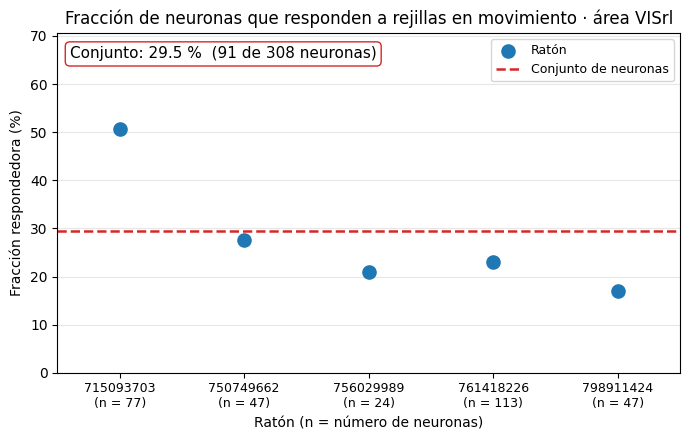

In [8]:
#Gaby

import warnings
import numpy as np
import matplotlib.pyplot as plt


def grafica_fraccion_por_raton(d, umbral=2.5, ventana=2.0, todas_combinadas=False):
    """Paso 6. Un punto por ratón con su fracción respondedora, una línea horizontal con la
    fracción del conjunto de neuronas, ejes rotulados, el número del conjunto dentro de la
    figura y el nombre del área en el título. Usa los mismos nombres de variables del Paso 5."""
    n_neu, n_ens = len(d["u_id"]), len(d["e_clase"])
    s_unidad = d["s_unidad"].astype(np.int64)
    s_ensayo = d["s_ensayo"].astype(np.int64)
    s_t = d["s_t"]

    # ---- Paso 3: tasa (Hz) de cada neurona en cada ensayo, PAs entre 0 y 2 s ----
    en_ventana = (s_t >= 0) & (s_t < ventana)
    llave = s_unidad[en_ventana] * n_ens + s_ensayo[en_ventana]
    tasas = np.bincount(llave, minlength=n_neu * n_ens).reshape(n_neu, n_ens) / ventana

    # ---- Paso 2: índices de los ensayos ----
    idx_rejillas = np.where(d["e_clase"] == "drifting_gratings")[0]
    idx_espont = np.where(d["e_clase"] == "spontaneous")[0]

    # ---- Paso 3: cada neurona solo con los ensayos de SU ratón (NaN en los demás) ----
    u_raton, e_raton = d["u_raton"], d["e_raton"]
    valido_evo = (u_raton[:, None] == e_raton[idx_rejillas][None, :])
    valido_bas = (u_raton[:, None] == e_raton[idx_espont][None, :])
    tasa_evocada = np.where(valido_evo, tasas[:, idx_rejillas], np.nan)
    tasa_basal = np.where(valido_bas, tasas[:, idx_espont], np.nan)

    # ---- Paso 4: Z-score por neurona ----
    mu_bas = np.nanmean(tasa_basal, axis=1)
    sd_bas = np.nanstd(tasa_basal, axis=1, ddof=1)

    with warnings.catch_warnings(), np.errstate(all="ignore"):
        warnings.simplefilter("ignore")
        if todas_combinadas:
            mu_evo = np.nanmean(tasa_evocada, axis=1)
        else:
            feats = np.column_stack([d[k][idx_rejillas].astype(float)
                                     for k in ["e_orientacion", "e_frec_temporal", "e_frec_espacial"]])
            feats = feats[:, ~np.all(np.isnan(feats), axis=0)]
            cond_valida = ~np.isnan(feats).any(axis=1)
            combos, inv = np.unique(feats[cond_valida], axis=0, return_inverse=True)
            inv = np.ravel(inv)
            cols_valid = np.where(cond_valida)[0]
            media_cond = np.column_stack([np.nanmean(tasa_evocada[:, cols_valid[inv == k]], axis=1)
                                          for k in range(len(combos))])
            mu_evo = np.nanmax(media_cond, axis=1)       # condición preferida (tasa máxima)
        z = (mu_evo - mu_bas) / sd_bas
        responde = (sd_bas > 0) & (z >= umbral)

    # ---- Paso 5: fracción por ratón y del conjunto ----
    ratones = np.unique(u_raton)
    n_por_raton = np.array([(u_raton == r).sum() for r in ratones])
    frac_por_raton = np.array([100 * responde[u_raton == r].mean() for r in ratones])
    n_resp = int(responde.sum())
    frac_conjunto = 100 * n_resp / n_neu

    # ---- Paso 6: gráfica ----
    fig, ax = plt.subplots(figsize=(7, 4.5))
    x = np.arange(len(ratones))
    ax.scatter(x, frac_por_raton, s=90, color="tab:blue", zorder=3, label="Ratón")
    ax.axhline(frac_conjunto, color="tab:red", linestyle="--", linewidth=1.8, zorder=2,
               label="Conjunto de neuronas")
    ax.text(0.02, 0.96, f"Conjunto: {frac_conjunto:.1f} %  ({n_resp} de {n_neu} neuronas)",
            transform=ax.transAxes, va="top", ha="left", fontsize=11,
            bbox=dict(boxstyle="round", facecolor="white", edgecolor="tab:red"))
    ax.set_xticks(x)
    ax.set_xticklabels([f"{int(r)}\n(n = {n})" for r, n in zip(ratones, n_por_raton)], fontsize=9)
    ax.set_xlabel("Ratón (n = número de neuronas)")
    ax.set_ylabel("Fracción respondedora (%)")
    ax.set_ylim(0, max(frac_por_raton.max(), frac_conjunto) + 20)
    ax.set_xlim(-0.5, len(ratones) - 0.5)
    ax.set_title(f"Fracción de neuronas que responden a rejillas en movimiento · área {str(d['area'])}")
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig("fraccion_por_raton.png", dpi=200)       # para el póster
    plt.show()


# Ejecutar
grafica_fraccion_por_raton(d)

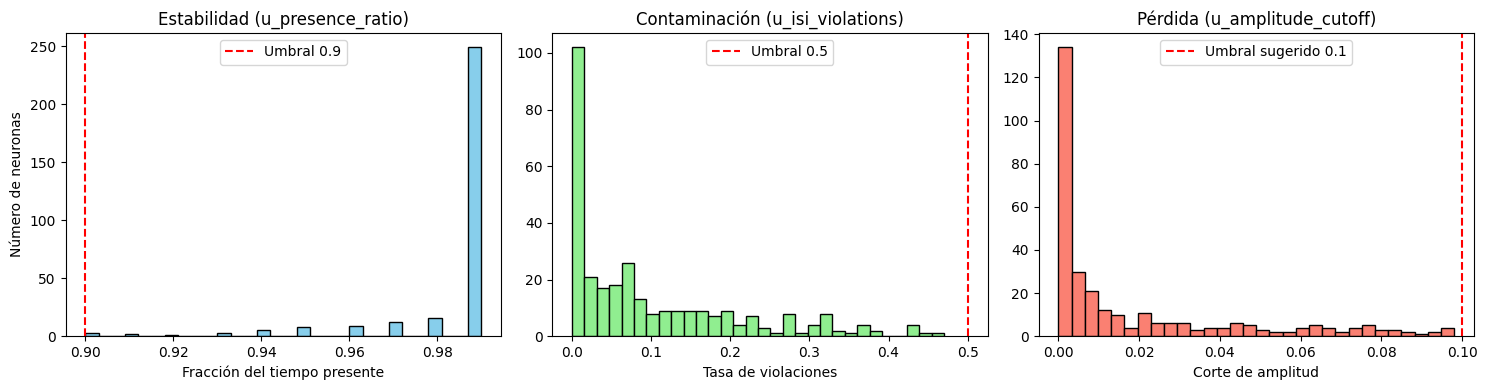

Total de neuronas iniciales: 308
Neuronas con presence_ratio > 0.9: 305
Neuronas con isi_violations < 0.5: 308
Neuronas que cumplen ambos: 305


In [9]:
#EVALUAR SI ES NECESARIO UN FILTRO DE CALIDAD
import numpy as np
import matplotlib.pyplot as plt

# Asumiendo que ya corriste la celda de descarga y tienes:
# d = np.load("datos.npz", allow_pickle=False)

# Extraer las métricas de calidad de las neuronas
presence_ratio = d['u_presence_ratio']
isi_violations = d['u_isi_violations']
amplitude_cutoff = d['u_amplitude_cutoff']

# Crear la figura con 3 paneles
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Estabilidad (Presence Ratio)
axes[0].hist(presence_ratio, bins=30, color='skyblue', edgecolor='black')
axes[0].set_title('Estabilidad (u_presence_ratio)')
axes[0].set_xlabel('Fracción del tiempo presente')
axes[0].set_ylabel('Número de neuronas')
axes[0].axvline(0.9, color='red', linestyle='dashed', linewidth=1.5, label='Umbral 0.9')
axes[0].legend()

# 2. Contaminación (ISI Violations)
axes[1].hist(isi_violations, bins=30, color='lightgreen', edgecolor='black')
axes[1].set_title('Contaminación (u_isi_violations)')
axes[1].set_xlabel('Tasa de violaciones')
axes[1].axvline(0.5, color='red', linestyle='dashed', linewidth=1.5, label='Umbral 0.5')
axes[1].legend()

# 3. Pérdida de espigas (Amplitude Cutoff)
axes[2].hist(amplitude_cutoff, bins=30, color='salmon', edgecolor='black')
axes[2].set_title('Pérdida (u_amplitude_cutoff)')
axes[2].set_xlabel('Corte de amplitud')
axes[2].axvline(0.1, color='red', linestyle='dashed', linewidth=1.5, label='Umbral sugerido 0.1')
axes[2].legend()

plt.tight_layout()
plt.show()

# Imprimir resumen numérico rápido
print(f"Total de neuronas iniciales: {len(presence_ratio)}")
print(f"Neuronas con presence_ratio > 0.9: {np.sum(presence_ratio > 0.9)}")
print(f"Neuronas con isi_violations < 0.5: {np.sum(isi_violations < 0.5)}")
print(f"Neuronas que cumplen ambos: {np.sum((presence_ratio > 0.9) & (isi_violations < 0.5))}")

NO HAY FILTRO ADICIONAL

 ya que tus datos ya están excepcionalmente limpios. Como menciona el documento del proyecto final, las neuronas entregadas ya vienen prefiltradas con criterios de calidad desde el Allen Institute.   Analizando tus métricas específicas:Contaminación (u_isi_violations): Las 308 neuronas de tu área ya cumplen con el umbral de < 0.5. Aplicar este filtro no eliminaría ninguna unidad.Pérdida (u_amplitude_cutoff): Visualmente en tu tercer histograma, absolutamente todas las neuronas caen por debajo del umbral de 0.1.Estabilidad (u_presence_ratio): 305 de tus 308 neuronas superan el umbral de > 0.9. Aplicar este filtro solo descartaría 3 neuronas, lo cual representa menos del 1% de tu muestra total.Puedes proceder con las 308 neuronas originales sin problema. Si por rigor metodológico decides filtrar esas 3 neuronas inestables (quedándote con 305), el documento exige que justifiques esta decisión de "apretar el criterio" en la sección de métodos de tu póster.  

---
## Para cerrar

Anoten su número: **la fracción de neuronas de su área que responden a las rejillas en movimiento**.

Ese número va al póster y es el que comparamos entre las once parejas el viernes 25. Puestos en
orden de área, los once juntos reconstruyen la jerarquía visual del ratón.

Guarden este notebook en su repositorio de GitHub. Es la primera pieza del pipeline del proyecto.

In [10]:
#PIPE LINE COMPLETO

In [11]:
import warnings
import numpy as np
import matplotlib.pyplot as plt

def graficar_psth_y_extraer_condiciones(d):
    """
    Figura 2 - Panel A: PSTH Poblacional.
    Calcula porcentajes de respuesta basados en la condición óptima de cada neurona
    e imprime cuáles son esas condiciones específicas (Orientación, Frecuencia, etc.).

    Actualización:
    - Simetría en ventanas temporales (Basal == Evocada):
        * Rejillas en Movimiento: Ventana de 2.0 s tanto para basal como evocada.
        * Rejillas Estáticas: Ventana de 0.25 s tanto para basal como evocada.
    """
    umbral = 2.5
    ventana_mov = 2.0
    ventana_est = 0.25

    n_neu, n_ens = len(d["u_id"]), len(d["e_clase"])
    s_unidad = d["s_unidad"].astype(np.int64)
    s_ensayo = d["s_ensayo"].astype(np.int64)
    s_t = d["s_t"]
    u_raton, e_raton = d["u_raton"], d["e_raton"]

    idx_mov = np.where(d["e_clase"] == "drifting_gratings")[0]
    idx_est = np.where(d["e_clase"] == "static_gratings")[0]
    idx_espont = np.where(d["e_clase"] == "spontaneous")[0]

    # =========================================================================
    # FUNCIÓN PARA EVALUAR CONDICIÓN PREFERIDA (BASAL Y EVOCADA IGUALES)
    # =========================================================================
    def evaluar_condicion_optima(idx_cond, caracteristicas, nombre_estimulo, ventana_cond):
        # 1. Conteo de espigas y conversión a Hz usando la ventana del estímulo
        en_ventana = (s_t >= 0) & (s_t < ventana_cond)
        llave = s_unidad[en_ventana] * n_ens + s_ensayo[en_ventana]
        tasas = np.bincount(llave, minlength=n_neu * n_ens).reshape(n_neu, n_ens) / ventana_cond

        # 2. Calcular ACTIVIDAD BASAL (espontánea) en la MISMA ventana temporal
        valido_bas = (u_raton[:, None] == e_raton[idx_espont][None, :])
        tasa_basal = np.where(valido_bas, tasas[:, idx_espont], np.nan)

        with warnings.catch_warnings(), np.errstate(all="ignore"):
            warnings.simplefilter("ignore")
            mu_bas = np.nanmean(tasa_basal, axis=1)
            sd_bas = np.nanstd(tasa_basal, axis=1, ddof=1)

        # 3. Calcular ACTIVIDAD EVOCADA para el estímulo específico
        valido_evo = (u_raton[:, None] == e_raton[idx_cond][None, :])
        tasa_evocada = np.where(valido_evo, tasas[:, idx_cond], np.nan)

        with warnings.catch_warnings(), np.errstate(all="ignore"):
            warnings.simplefilter("ignore")

            # Extraer características del estímulo para estos ensayos
            feats = np.column_stack([d[k][idx_cond].astype(float) for k in caracteristicas])
            feats = feats[:, ~np.all(np.isnan(feats), axis=0)]
            cond_valida = ~np.isnan(feats).any(axis=1)

            if not cond_valida.any():
                return 0.0 # Respaldo si no hay sub-condiciones válidas

            # Identificar todas las combinaciones únicas de estímulos
            combos, inv = np.unique(feats[cond_valida], axis=0, return_inverse=True)
            inv = np.ravel(inv)
            cols_valid = np.where(cond_valida)[0]

            # Calcular la media para cada combinación
            media_cond = np.column_stack([np.nanmean(tasa_evocada[:, cols_valid[inv == k]], axis=1)
                                          for k in range(len(combos))])

            # Extraer la tasa máxima y el ÍNDICE de la combinación óptima
            mu_evo = np.nanmax(media_cond, axis=1)
            idx_optimo = np.nanargmax(media_cond, axis=1)

            # Calcular Z-score (Basal y Evocada medidas exactamente bajo la misma ventana)
            z = (mu_evo - mu_bas) / sd_bas
            responde = (sd_bas > 0) & (z >= umbral)

            # -- IMPRESIÓN DE RESULTADOS --
            idx_responsivas = np.where(responde)[0]
            pct_respuesta = (len(idx_responsivas) / n_neu) * 100

            print(f"\n{'='*60}")
            print(f"ESTÍMULO: {nombre_estimulo.upper()} (Ventana Basal/Evocada: {ventana_cond}s) | Respuestas: {len(idx_responsivas)} de {n_neu} ({pct_respuesta:.1f}%)")
            print(f"{'='*60}")

            if len(idx_responsivas) > 0:
                print("Mostrando las condiciones óptimas para las primeras 15 neuronas responsivas:")
                for i_neu in idx_responsivas[:15]:
                    combo_ganador = combos[idx_optimo[i_neu]]
                    parametros_str = " | ".join([f"{caracteristicas[j].replace('e_', '')}: {combo_ganador[j]}"
                                                 for j in range(len(caracteristicas))])
                    print(f"  Neurona {i_neu:>3} -> Z-score: {z[i_neu]:>5.1f} | Óptimo: [{parametros_str}]")
                if len(idx_responsivas) > 15:
                    print(f"  ... y {len(idx_responsivas) - 15} neuronas más.")
            else:
                print("Ninguna neurona superó el umbral Z para este estímulo.")

            return pct_respuesta

    # Características a evaluar
    feats_mov = ["e_orientacion", "e_frec_temporal", "e_frec_espacial"]
    feats_est = ["e_orientacion", "e_frec_espacial", "e_fase"]

    # Validar si existe 'e_fase' en el diccionario para estáticas, si no, omitir
    if "e_fase" not in d:
        feats_est = ["e_orientacion", "e_frec_espacial"]

    # Evaluación con sus respectivas ventanas temporales simétricas
    pct_mov = evaluar_condicion_optima(idx_mov, feats_mov, "Rejillas en Movimiento", ventana_mov)
    pct_est = evaluar_condicion_optima(idx_est, feats_est, "Rejillas Estáticas", ventana_est)

# Ejecutar:
graficar_psth_y_extraer_condiciones(d)


ESTÍMULO: REJILLAS EN MOVIMIENTO (Ventana Basal/Evocada: 2.0s) | Respuestas: 91 de 308 (29.5%)
Mostrando las condiciones óptimas para las primeras 15 neuronas responsivas:
  Neurona   4 -> Z-score:   3.2 | Óptimo: [orientacion: 180.0 | frec_temporal: 1.0 | frec_espacial: 0.03999999910593033]
  Neurona   5 -> Z-score:  50.2 | Óptimo: [orientacion: 180.0 | frec_temporal: 1.0 | frec_espacial: 0.03999999910593033]
  Neurona  13 -> Z-score:   3.2 | Óptimo: [orientacion: 180.0 | frec_temporal: 1.0 | frec_espacial: 0.03999999910593033]
  Neurona  18 -> Z-score:   3.3 | Óptimo: [orientacion: 135.0 | frec_temporal: 1.0 | frec_espacial: 0.03999999910593033]
  Neurona  20 -> Z-score:   3.4 | Óptimo: [orientacion: 0.0 | frec_temporal: 2.0 | frec_espacial: 0.03999999910593033]
  Neurona  31 -> Z-score:   5.3 | Óptimo: [orientacion: 45.0 | frec_temporal: 1.0 | frec_espacial: 0.03999999910593033]
  Neurona  33 -> Z-score:   9.4 | Óptimo: [orientacion: 180.0 | frec_temporal: 1.0 | frec_espacial: 0.03

FIGURA 1

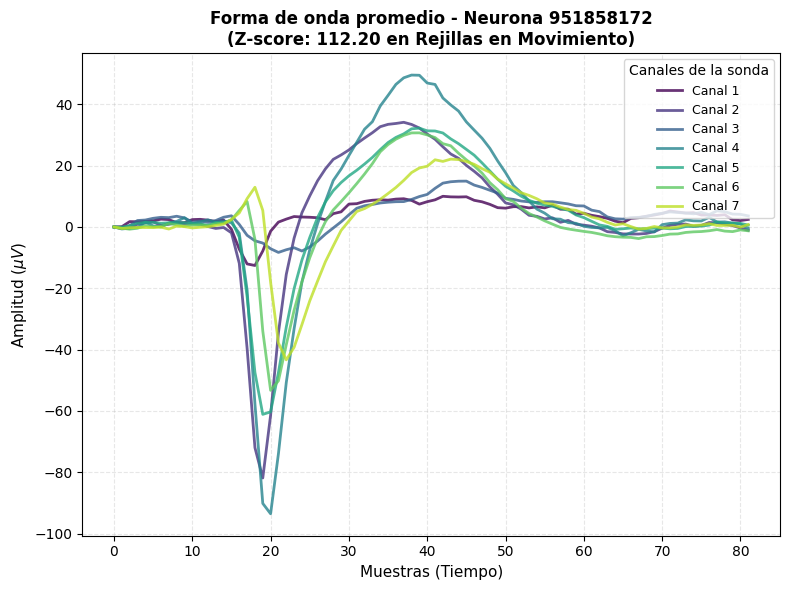

In [12]:
#PAnel c correguido
import warnings
import numpy as np
import matplotlib.pyplot as plt

def graficar_forma_onda_panel_c(d):
    """
    Figura 2 - Panel C: Forma de onda de la neurona más responsiva.
    Calcula internamente el Z-score usando las variables y la lógica del Panel A,
    buscando la neurona con mayor respuesta a las rejillas en movimiento.
    """
    umbral = 2.5
    ventana = 2.0

    n_neu, n_ens = len(d["u_id"]), len(d["e_clase"])
    s_unidad = d["s_unidad"].astype(np.int64)
    s_ensayo = d["s_ensayo"].astype(np.int64)
    s_t = d["s_t"]
    u_raton, e_raton = d["u_raton"], d["e_raton"]

    # =========================================================================
    # 1. CÁLCULO DE TASAS Y ACTIVIDAD BASAL
    # =========================================================================
    en_ventana = (s_t >= 0) & (s_t < ventana)
    llave = s_unidad[en_ventana] * n_ens + s_ensayo[en_ventana]
    tasas = np.bincount(llave, minlength=n_neu * n_ens).reshape(n_neu, n_ens) / ventana

    idx_espont = np.where(d["e_clase"] == "spontaneous")[0]
    valido_bas = (u_raton[:, None] == e_raton[idx_espont][None, :])
    tasa_basal = np.where(valido_bas, tasas[:, idx_espont], np.nan)

    with warnings.catch_warnings(), np.errstate(all="ignore"):
        warnings.simplefilter("ignore")
        mu_bas = np.nanmean(tasa_basal, axis=1)
        sd_bas = np.nanstd(tasa_basal, axis=1, ddof=1)

    # =========================================================================
    # 2. CÁLCULO DEL Z-SCORE MÁXIMO (Drifting Gratings)
    # =========================================================================
    idx_mov = np.where(d["e_clase"] == "drifting_gratings")[0]
    valido_evo = (u_raton[:, None] == e_raton[idx_mov][None, :])
    tasa_evocada = np.where(valido_evo, tasas[:, idx_mov], np.nan)

    caracteristicas = ["e_orientacion", "e_frec_temporal", "e_frec_espacial"]

    with warnings.catch_warnings(), np.errstate(all="ignore"):
        warnings.simplefilter("ignore")
        feats = np.column_stack([d[k][idx_mov].astype(float) for k in caracteristicas])
        feats = feats[:, ~np.all(np.isnan(feats), axis=0)]
        cond_valida = ~np.isnan(feats).any(axis=1)

        if cond_valida.any():
            combos, inv = np.unique(feats[cond_valida], axis=0, return_inverse=True)
            inv = np.ravel(inv)
            cols_valid = np.where(cond_valida)[0]

            # Calcular la media para cada combinación y extraer la máxima (mu_evo)
            media_cond = np.column_stack([np.nanmean(tasa_evocada[:, cols_valid[inv == k]], axis=1)
                                          for k in range(len(combos))])
            mu_evo = np.nanmax(media_cond, axis=1)
            z = (mu_evo - mu_bas) / sd_bas
        else:
            z = np.zeros(n_neu)

    # =========================================================================
    # 3. SELECCIONAR LA NEURONA CON EL MAYOR Z-SCORE
    # =========================================================================
    # Reemplazar NaNs por -infinito para evitar errores al buscar el máximo
    z_seguro = np.where(np.isnan(z), -np.inf, z)
    idx_neu = np.argmax(z_seguro)
    z_max = z_seguro[idx_neu]
    id_neu = d["u_id"][idx_neu]

    if z_max >= umbral:
        titulo_extra = f"(Z-score: {z_max:.2f} en Rejillas en Movimiento)"
    else:
        print("Advertencia: Ninguna neurona superó el Z-score de 2.5.")
        print(f"Graficando la neurona con mayor valor relativo (Z = {z_max:.2f}) como respaldo.")
        titulo_extra = f"(Neurona de respaldo - No alcanzó el Z-score, max: {z_max:.2f})"

    # =========================================================================
    # 4. GRAFICAR FORMA DE ONDA (PANEL C)
    # =========================================================================
    forma_onda = d["u_onda"][idx_neu]

    fig, ax = plt.subplots(figsize=(8, 6))

    # Paleta de colores para diferenciar los canales
    colores = plt.cm.viridis(np.linspace(0, 0.9, len(forma_onda)))

    for i, canal in enumerate(forma_onda):
        ax.plot(canal, color=colores[i], linewidth=2, alpha=0.8, label=f"Canal {i+1}")

    # Formato estético y etiquetas
    ax.set_title(f"Forma de onda promedio - Neurona {id_neu}\n{titulo_extra}", fontweight='bold', fontsize=12)
    ax.set_xlabel("Muestras (Tiempo)", fontsize=11)
    ax.set_ylabel(r"Amplitud ($\mu V$)", fontsize=11)

    # ax.invert_yaxis() # Descomenta si prefieres los picos de acción hacia abajo

    ax.grid(alpha=0.3, linestyle="--")
    ax.legend(loc="upper right", fontsize=9, title="Canales de la sonda")

    plt.tight_layout()
    plt.show()

# Ejecutar pasando únicamente el diccionario original
graficar_forma_onda_panel_c(d)

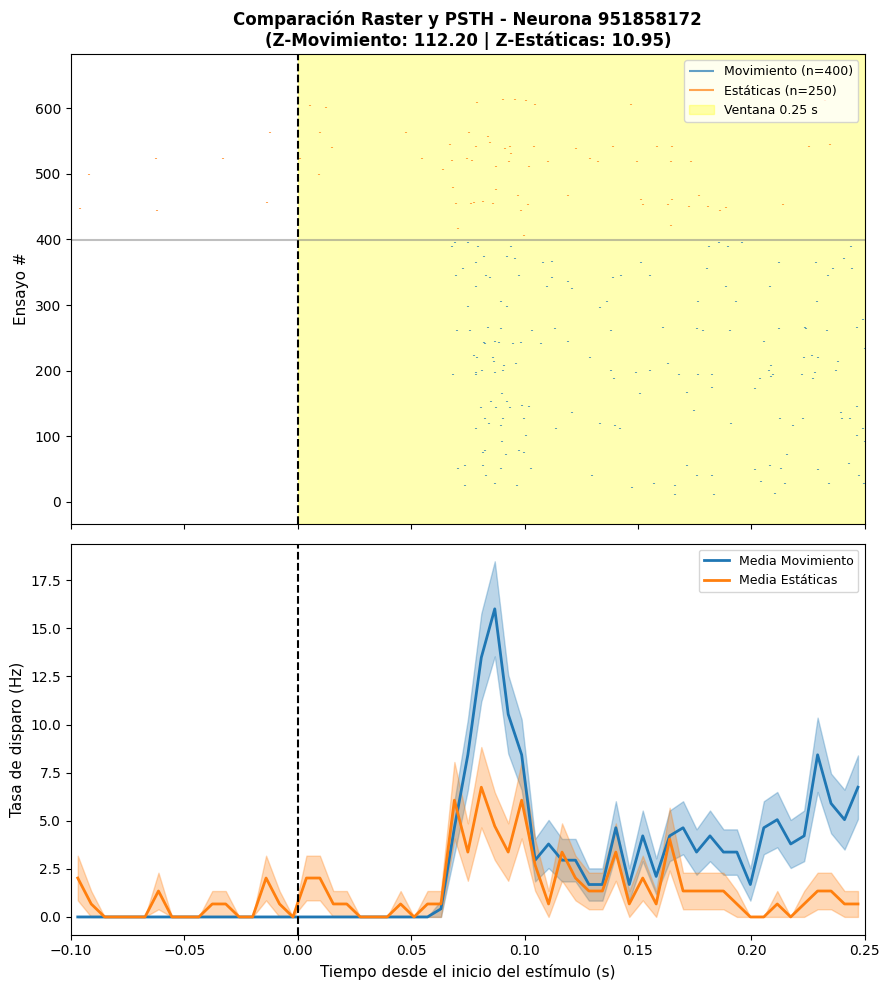

In [13]:
#Panel D

import warnings
import numpy as np
import matplotlib.pyplot as plt

def graficar_comparacion_panel_d(d):
    """
    Panel D: Genera el Raster y el PSTH comparativo (Línea + SEM) en una sola figura
    para Rejillas en Movimiento vs. Rejillas Estáticas.
    Calcula internamente las tasas, la actividad basal y los Z-scores (z_A y z_B)
    usando la misma lógica del Panel A, para seleccionar la neurona de mayor respuesta.
    """
    umbral = 2.5
    ventana = 2.0

    n_neu, n_ens = len(d["u_id"]), len(d["e_clase"])
    s_unidad = d["s_unidad"].astype(np.int64)
    s_ensayo = d["s_ensayo"].astype(np.int64)
    s_t = d["s_t"]
    u_raton, e_raton = d["u_raton"], d["e_raton"]

    # =========================================================================
    # 1. CÁLCULO DE TASAS Y ACTIVIDAD BASAL (ESPONTÁNEA)
    # =========================================================================
    en_ventana = (s_t >= 0) & (s_t < ventana)
    llave = s_unidad[en_ventana] * n_ens + s_ensayo[en_ventana]
    tasas = np.bincount(llave, minlength=n_neu * n_ens).reshape(n_neu, n_ens) / ventana

    idx_espont = np.where(d["e_clase"] == "spontaneous")[0]
    valido_bas = (u_raton[:, None] == e_raton[idx_espont][None, :])
    tasa_basal = np.where(valido_bas, tasas[:, idx_espont], np.nan)

    with warnings.catch_warnings(), np.errstate(all="ignore"):
        warnings.simplefilter("ignore")
        mu_bas = np.nanmean(tasa_basal, axis=1)
        sd_bas = np.nanstd(tasa_basal, axis=1, ddof=1)

    # =========================================================================
    # 2. FUNCIÓN AUXILIAR PARA OBTENER Z-SCORE POR CONDICIÓN DE ESTÍMULO
    # =========================================================================
    def calcular_z_score_condicion(cond_clase, caracteristicas):
        idx_cond = np.where(d["e_clase"] == cond_clase)[0]
        if len(idx_cond) == 0:
            return np.full(n_neu, np.nan)

        valido_evo = (u_raton[:, None] == e_raton[idx_cond][None, :])
        tasa_evocada = np.where(valido_evo, tasas[:, idx_cond], np.nan)

        with warnings.catch_warnings(), np.errstate(all="ignore"):
            warnings.simplefilter("ignore")
            # Extraer solo las características presentes en el diccionario
            feats_list = [d[k][idx_cond].astype(float) for k in caracteristicas if k in d]
            if not feats_list:
                return np.full(n_neu, np.nan)

            feats = np.column_stack(feats_list)
            feats = feats[:, ~np.all(np.isnan(feats), axis=0)]
            cond_valida = ~np.isnan(feats).any(axis=1)

            if not cond_valida.any():
                return np.full(n_neu, np.nan)

            combos, inv = np.unique(feats[cond_valida], axis=0, return_inverse=True)
            inv = np.ravel(inv)
            cols_valid = np.where(cond_valida)[0]

            media_cond = np.column_stack([np.nanmean(tasa_evocada[:, cols_valid[inv == k]], axis=1)
                                          for k in range(len(combos))])
            mu_evo = np.nanmax(media_cond, axis=1)
            z = (mu_evo - mu_bas) / sd_bas
            return z

    # Obtener Z-scores para movimiento (A) y estáticas (B)
    feats_mov = ["e_orientacion", "e_frec_temporal", "e_frec_espacial"]
    feats_est = ["e_orientacion", "e_frec_espacial", "e_fase"]

    z_A = calcular_z_score_condicion("drifting_gratings", feats_mov)
    z_B = calcular_z_score_condicion("static_gratings", feats_est)

    # =========================================================================
    # 3. SELECCIÓN DE LA NEURONA DE EJEMPLO
    # =========================================================================
    z_A_seguro = np.where(np.isnan(z_A), -np.inf, z_A)
    idx_neu = np.argmax(z_A_seguro)
    z_A_val = z_A[idx_neu]
    z_B_val = z_B[idx_neu] if not np.isnan(z_B[idx_neu]) else 0.0
    id_neu = d["u_id"][idx_neu]

    if z_A_val >= umbral:
        titulo_extra = f"(Z-Movimiento: {z_A_val:.2f} | Z-Estáticas: {z_B_val:.2f})"
    else:
        print("Advertencia: Ninguna neurona superó el Z-score de 2.5.")
        print(f"Graficando neurona {id_neu} de respaldo.")
        titulo_extra = f"(Neurona de respaldo - Z-Mov: {z_A_val:.2f} | Z-Est: {z_B_val:.2f})"

    raton_neu = d["u_raton"][idx_neu]

    # =========================================================================
    # 4. EXTRACCIÓN DE ESPIGAS PARA AMBAS CONDICIONES
    # =========================================================================
    cond_A = "drifting_gratings"
    cond_B = "static_gratings"

    idx_ensayos_A = np.where((d["e_clase"] == cond_A) & (d["e_raton"] == raton_neu))[0]
    idx_ensayos_B = np.where((d["e_clase"] == cond_B) & (d["e_raton"] == raton_neu))[0]

    mascara_neu = (s_unidad == idx_neu)
    spikes_t_neu = s_t[mascara_neu]
    spikes_ens_neu = s_ensayo[mascara_neu]

    raster_A = [spikes_t_neu[spikes_ens_neu == ens] for ens in idx_ensayos_A]
    raster_B = [spikes_t_neu[spikes_ens_neu == ens] for ens in idx_ensayos_B]

    # =========================================================================
    # 5. CREACIÓN DE LA GRÁFICA COMPARATIVA
    # =========================================================================
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 10), sharex=True, gridspec_kw={'height_ratios': [1.2, 1]})
    lim_inf, lim_sup = -0.1, 0.25

    # --- RASTER PLOT APILADO ---
    offsets_A = np.arange(len(raster_A))
    offsets_B = np.arange(len(raster_B)) + len(raster_A)

    if len(raster_A) > 0:
        ax1.eventplot(raster_A, lineoffsets=offsets_A, color="tab:blue", linelengths=0.8, alpha=0.7, label=f"Movimiento (n={len(raster_A)})")

    if len(raster_B) > 0:
        ax1.eventplot(raster_B, lineoffsets=offsets_B, color="tab:orange", linelengths=0.8, alpha=0.7, label=f"Estáticas (n={len(raster_B)})")
        ax1.axhline(len(raster_A) - 0.5, color="gray", linestyle="-", linewidth=1.5, alpha=0.5)

    ax1.axvline(0, color="k", linestyle="--", linewidth=1.5)
    ax1.axvspan(0, 0.25, color='yellow', alpha=0.3, label="Ventana 0.25 s")

    ax1.set_title(f"Comparación Raster y PSTH - Neurona {id_neu}\n{titulo_extra}", fontweight='bold')
    ax1.set_ylabel("Ensayo #", fontsize=11)

    handles, labels = ax1.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax1.legend(by_label.values(), by_label.keys(), loc="upper right", fontsize=9)

    # --- PSTH EN LÍNEA SUPERPUESTO (CON SEM) ---
    num_bins = 60
    bins = np.linspace(lim_inf, lim_sup, num_bins)
    ancho_bin = bins[1] - bins[0]
    centros_bins = bins[:-1] + ancho_bin / 2

    def calcular_media_sem(datos_raster):
        if len(datos_raster) == 0:
            return np.zeros_like(centros_bins), np.zeros_like(centros_bins)
        tasas_local = np.zeros((len(datos_raster), len(centros_bins)))
        for i, espigas in enumerate(datos_raster):
            conteos, _ = np.histogram(espigas, bins=bins)
            tasas_local[i, :] = conteos / ancho_bin
        media = np.mean(tasas_local, axis=0)
        sem = np.std(tasas_local, axis=0) / np.sqrt(len(datos_raster))
        return media, sem

    media_A, sem_A = calcular_media_sem(raster_A)
    media_B, sem_B = calcular_media_sem(raster_B)

    # Graficar Condición A (Movimiento)
    if len(raster_A) > 0:
        ax2.plot(centros_bins, media_A, color="tab:blue", linewidth=2, label="Media Movimiento")
        ax2.fill_between(centros_bins, np.maximum(0, media_A - sem_A), media_A + sem_A, color="tab:blue", alpha=0.3)

    # Graficar Condición B (Estáticas)
    if len(raster_B) > 0:
        ax2.plot(centros_bins, media_B, color="tab:orange", linewidth=2, label="Media Estáticas")
        ax2.fill_between(centros_bins, np.maximum(0, media_B - sem_B), media_B + sem_B, color="tab:orange", alpha=0.3)

    ax2.axvline(0, color="k", linestyle="--", linewidth=1.5)
    ax2.set_xlabel("Tiempo desde el inicio del estímulo (s)", fontsize=11)
    ax2.set_ylabel("Tasa de disparo (Hz)", fontsize=11)
    ax2.set_xlim(lim_inf, lim_sup)
    ax2.legend(loc="upper right", fontsize=9)

    plt.tight_layout()
    plt.show()

# Ejecutar pasando únicamente el diccionario original:
graficar_comparacion_panel_d(d)

In [14]:
#PASO 2 (figura 2)

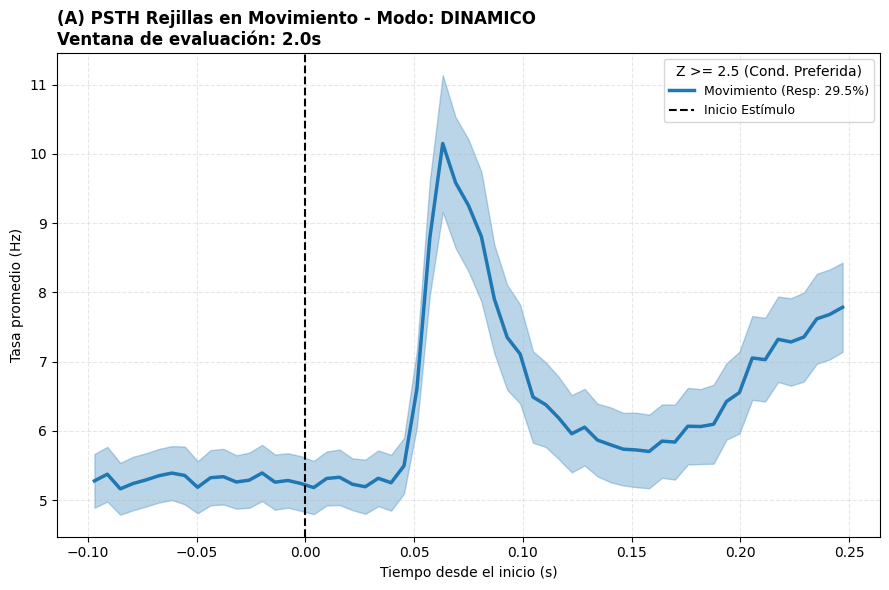

In [15]:
#panel A Figura 2

import warnings
import numpy as np
import matplotlib.pyplot as plt

def graficar_panelA_movimiento(d, modo_ventana="dinamico"):
    umbral = 2.5
    n_neu, n_ens = len(d["u_id"]), len(d["e_clase"])
    s_unidad, s_ensayo, s_t = d["s_unidad"].astype(np.int64), d["s_ensayo"].astype(np.int64), d["s_t"]
    u_raton, e_raton = d["u_raton"], d["e_raton"]

    idx_mov = np.where(d["e_clase"] == "drifting_gratings")[0]
    idx_espont = np.where(d["e_clase"] == "spontaneous")[0]

    def calcular_porcentaje(idx_cond, caracteristicas, ventana):
        # 1. Calcular tasas limitadas a la ventana exacta
        en_ventana = (s_t >= 0) & (s_t < ventana)
        llave = s_unidad[en_ventana] * n_ens + s_ensayo[en_ventana]
        tasas = np.bincount(llave, minlength=n_neu * n_ens).reshape(n_neu, n_ens) / ventana

        # 2. Basal emparejado a la misma ventana
        valido_bas = (u_raton[:, None] == e_raton[idx_espont][None, :])
        tasa_basal = np.where(valido_bas, tasas[:, idx_espont], np.nan)
        mu_bas = np.nanmean(tasa_basal, axis=1)
        sd_bas = np.nanstd(tasa_basal, axis=1, ddof=1)
        sd_bas_segura = np.where(sd_bas == 0, np.inf, sd_bas)

        # 3. Evocada
        valido_evo = (u_raton[:, None] == e_raton[idx_cond][None, :])
        tasa_evocada = np.where(valido_evo, tasas[:, idx_cond], np.nan)

        # 4. Lógica de Condición Preferida
        with warnings.catch_warnings(), np.errstate(all="ignore"):
            warnings.simplefilter("ignore")
            feats = np.column_stack([d[k][idx_cond].astype(float) for k in caracteristicas])
            feats = feats[:, ~np.all(np.isnan(feats), axis=0)]
            cond_valida = ~np.isnan(feats).any(axis=1)

            if not cond_valida.any():
                mu_evo = np.nanmean(tasa_evocada, axis=1)
            else:
                combos, inv = np.unique(feats[cond_valida], axis=0, return_inverse=True)
                inv = np.ravel(inv)
                cols_valid = np.where(cond_valida)[0]
                media_cond = np.column_stack([np.nanmean(tasa_evocada[:, cols_valid[inv == k]], axis=1)
                                              for k in range(len(combos))])
                mu_evo = np.nanmax(media_cond, axis=1)

            z = (mu_evo - mu_bas) / sd_bas_segura
            responde = (sd_bas_segura > 0) & (z >= umbral)
            return (responde.sum() / n_neu) * 100

    # Configurar ventana
    ventana_mov = 2.0 if modo_ventana == "dinamico" else 0.25
    feats_mov = ["e_orientacion", "e_frec_temporal", "e_frec_espacial"]

    pct_mov = calcular_porcentaje(idx_mov, feats_mov, ventana_mov)

    # Ampliamos los límites del PSTH para ver los 2.0 segundos completos del movimiento
    lim_inf, lim_sup, num_bins = -0.1, 0.25, 60
    bins = np.linspace(lim_inf, lim_sup, num_bins)
    ancho_bin = bins[1] - bins[0]
    centros = bins[:-1] + ancho_bin / 2

    def obtener_psth(idx_cond):
        psth = []
        for i_neu in range(n_neu):
            r_actual = u_raton[i_neu]
            idx_raton = idx_cond[e_raton[idx_cond] == r_actual]
            if len(idx_raton) > 0:
                t_neu = s_t[s_unidad == i_neu]
                ens_neu = s_ensayo[s_unidad == i_neu]
                tasas_m = np.zeros((len(idx_raton), len(centros)))
                for k, ens in enumerate(idx_raton):
                    conteos, _ = np.histogram(t_neu[ens_neu == ens], bins=bins)
                    tasas_m[k, :] = conteos / ancho_bin
                psth.append(np.mean(tasas_m, axis=0))
        return np.array(psth)

    psth_mov = obtener_psth(idx_mov)

    fig, ax = plt.subplots(figsize=(9, 6))
    if len(psth_mov) > 0:
        mu_m, sem_m = np.mean(psth_mov, axis=0), np.std(psth_mov, axis=0) / np.sqrt(len(psth_mov))
        ax.plot(centros, mu_m, color="tab:blue", lw=2.5, label=f"Movimiento (Resp: {pct_mov:.1f}%)")
        ax.fill_between(centros, np.maximum(0, mu_m - sem_m), mu_m + sem_m, color="tab:blue", alpha=0.3)

    ax.axvline(0, color="k", ls="--", lw=1.5, label="Inicio Estímulo")


    ax.set_title(f"(A) PSTH Rejillas en Movimiento - Modo: {modo_ventana.upper()}\nVentana de evaluación: {ventana_mov}s", fontweight='bold', loc='left')
    ax.set_xlabel("Tiempo desde el inicio (s)")
    ax.set_ylabel("Tasa promedio (Hz)")
    ax.legend(loc="upper right", fontsize=9, title="Z >= 2.5 (Cond. Preferida)")
    ax.grid(alpha=0.3, ls="--")
    plt.tight_layout()
    plt.show()

# Ejecutar el panel filtrado
graficar_panelA_movimiento(d, modo_ventana="dinamico")


EN EL CODIGO, HAY añadido un parámetro llamado modo_ventana. Si lo configures como "dinamico", calculará la tasa basal y evocada usando 2.0s para movimiento y 0.25s para estáticas. Si lo cambias a "fijo", evaluará absolutamente todo (basal y ambos estímulos) enfocándose exclusivamente en la ráfaga inicial de 0.25s.

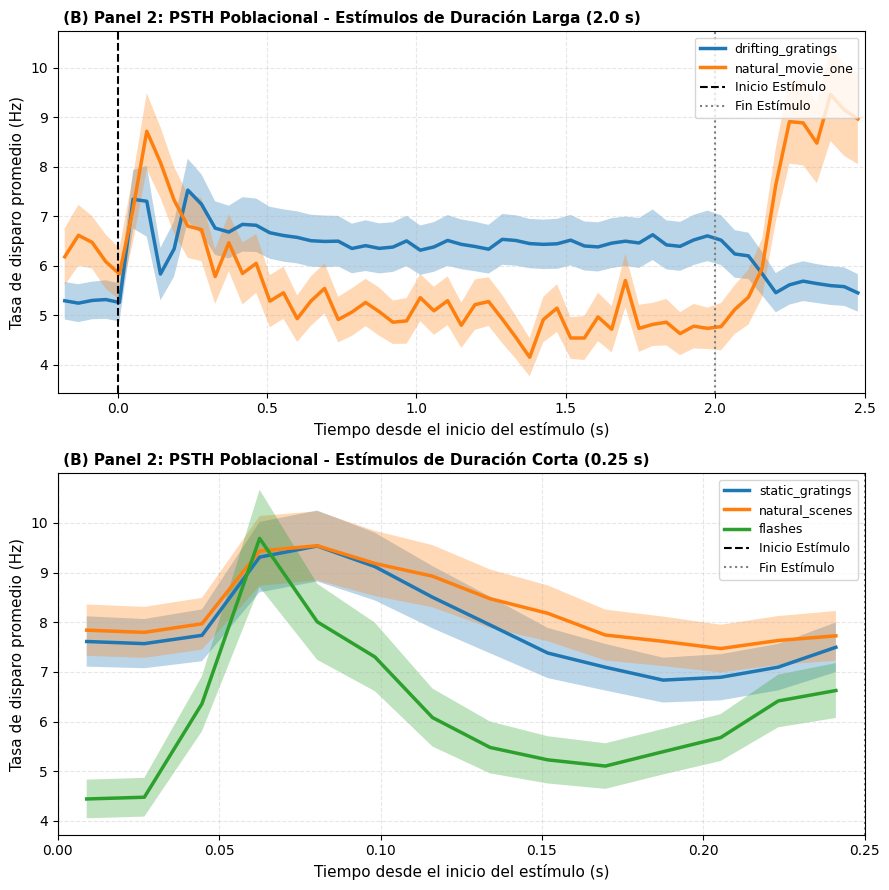

In [16]:
#Panel B
import numpy as np
import matplotlib.pyplot as plt

def graficar_psth_agrupado_por_duracion(d):
    """
    Figura 2 - Panel B (o Panel 2): PSTH Poblacional por clases de estímulo.
    Agrupa los estímulos según su duración para evitar mezclar ventanas
    temporales incompatibles.
    """
    u_id = d["u_id"]
    u_raton = d["u_raton"]
    e_clase = d["e_clase"]
    e_raton = d["e_raton"]
    s_unidad = d["s_unidad"].astype(np.int64)
    s_ensayo = d["s_ensayo"].astype(np.int64)
    s_t = d["s_t"]

    n_neu = len(u_id)

    # 1. Definir agrupaciones por duración
    grupos_duracion = {
        "Larga (2.0 s)": ["drifting_gratings", "natural_movie_one", "natural_movie_three"],
        "Corta (0.25 s)": ["static_gratings", "natural_scenes", "flashes"]
    }

    # Encontrar qué estímulos están realmente presentes
    clases_presentes = np.unique(e_clase)

    # Filtrar clases válidas
    grupos_activos = {}
    for nombre_grupo, clases in grupos_duracion.items():
        clases_validas = [c for c in clases if c in clases_presentes]
        if len(clases_validas) > 0:
            grupos_activos[nombre_grupo] = clases_validas

    # 2. Configuración dinámica de la figura
    n_grupos = len(grupos_activos)
    fig, axes = plt.subplots(n_grupos, 1, figsize=(9, 4.5 * n_grupos), sharey=False)

    if n_grupos == 1:
        axes = [axes]

    # 3. Cálculo y graficación independiente por grupo
    for idx_ax, (nombre_grupo, clases) in enumerate(grupos_activos.items()):
        ax = axes[idx_ax]

        # NUEVO: Ajustar límite inferior, superior y resolución de bins por grupo
        if "2.0" in nombre_grupo:
            lim_inf = -0.2
            lim_sup = 2.5
            num_bins = 60
        else:
            lim_inf = 0.0   # Inicia exactamente con el estímulo
            lim_sup = 0.25  # Termina exactamente con el estímulo
            num_bins = 15   # Se reduce el número de bins porque la ventana temporal es menor

        bins = np.linspace(lim_inf, lim_sup, num_bins)
        ancho_bin = bins[1] - bins[0]
        centros_bins = bins[:-1] + ancho_bin / 2

        for clase in clases:
            psth_clase = []

            for i_neu in range(n_neu):
                raton_actual = u_raton[i_neu]
                idx_ensayos = np.where((e_clase == clase) & (e_raton == raton_actual))[0]

                if len(idx_ensayos) == 0:
                    continue

                mascara_neu = (s_unidad == i_neu)
                t_neu = s_t[mascara_neu]
                ens_neu = s_ensayo[mascara_neu]

                tasas_ensayos = np.zeros((len(idx_ensayos), len(centros_bins)))

                for k, ens in enumerate(idx_ensayos):
                    conteos, _ = np.histogram(t_neu[ens_neu == ens], bins=bins)
                    tasas_ensayos[k, :] = conteos / ancho_bin

                psth_clase.append(np.mean(tasas_ensayos, axis=0))

            if len(psth_clase) > 0:
                psth_clase = np.array(psth_clase)
                media_pob = np.mean(psth_clase, axis=0)
                sem_pob = np.std(psth_clase, axis=0) / np.sqrt(len(psth_clase))

                ax.plot(centros_bins, media_pob, linewidth=2.5, label=f"{clase}")
                ax.fill_between(centros_bins, np.maximum(0, media_pob - sem_pob), media_pob + sem_pob, alpha=0.3)

        # 4. Estética de cada subgráfico
        ax.axvline(0, color="k", linestyle="--", linewidth=1.5, label="Inicio Estímulo")
        fin_estimulo = 2.0 if "2.0" in nombre_grupo else 0.25
        ax.axvline(fin_estimulo, color="gray", linestyle=":", linewidth=1.5, label="Fin Estímulo")

        ax.set_title(f" (B) Panel 2: PSTH Poblacional - Estímulos de Duración {nombre_grupo}", fontweight='bold', fontsize=11, loc='left')
        ax.set_xlabel("Tiempo desde el inicio del estímulo (s)", fontsize=11)
        ax.set_ylabel("Tasa de disparo promedio (Hz)", fontsize=11)
        ax.set_xlim(lim_inf, lim_sup)
        ax.legend(loc="upper right", fontsize=9)
        ax.grid(alpha=0.3, linestyle="--")

    plt.tight_layout()
    plt.show()

graficar_psth_agrupado_por_duracion(d)

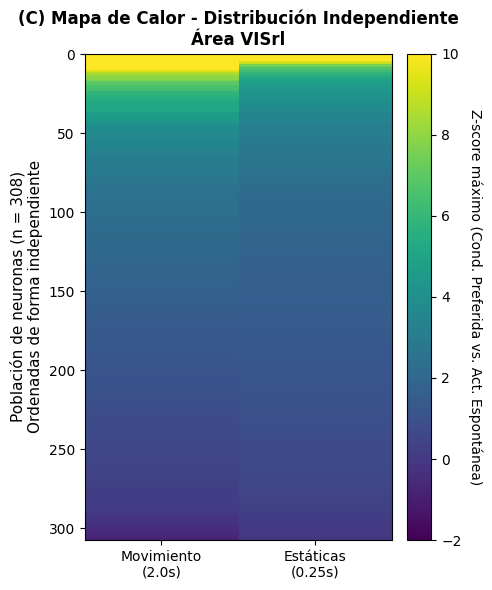

In [17]:
#PABEL C
import warnings
import numpy as np
import matplotlib.pyplot as plt

def graficar_panelC_independiente(d, modo_ventana="dinamico"):
    """
    Figura 2 - Panel C: Mapa de calor de Z-scores (Columnas Independientes).
    Utiliza la CONDICIÓN PREFERIDA (máxima respuesta agrupando por combinación).

    Cada columna se ordena de manera independiente de mayor a menor Z-score.
    NOTA: Las filas ya no representan a la misma neurona en ambas columnas.
    """
    n_neu, n_ens = len(d["u_id"]), len(d["e_clase"])
    s_unidad = d["s_unidad"].astype(np.int64)
    s_ensayo = d["s_ensayo"].astype(np.int64)
    s_t = d["s_t"]
    e_clase = d["e_clase"]
    u_raton, e_raton = d["u_raton"], d["e_raton"]

    # Configurar ventanas según el modo elegido
    ventana_mov = 2.0 if modo_ventana == "dinamico" else 0.25
    ventana_est = 0.25
    clases = [("drifting_gratings", ventana_mov), ("static_gratings", ventana_est)]

    idx_espont = np.where(e_clase == "spontaneous")[0]
    z_matrix = np.zeros((n_neu, 2))

    # Características clave del estímulo para encontrar la condición preferida
    caracteristicas_base = ["e_orientacion", "e_frec_temporal", "e_frec_espacial"]

    for j, (clase, ventana) in enumerate(clases):
        # 1. Calcular tasas limitadas a la ventana exacta
        en_ventana = (s_t >= 0) & (s_t < ventana)
        llave = s_unidad[en_ventana] * n_ens + s_ensayo[en_ventana]
        tasas = np.bincount(llave, minlength=n_neu * n_ens).reshape(n_neu, n_ens) / ventana

        # 2. Basal emparejada a la misma ventana temporal
        valido_bas = (u_raton[:, None] == e_raton[idx_espont][None, :])
        tasa_basal = np.where(valido_bas, tasas[:, idx_espont], np.nan)

        with warnings.catch_warnings(), np.errstate(all="ignore"):
            warnings.simplefilter("ignore")
            mu_bas = np.nanmean(tasa_basal, axis=1)
            sd_bas = np.nanstd(tasa_basal, axis=1, ddof=1)
            sd_bas_segura = np.where(sd_bas == 0, np.inf, sd_bas)

            # 3. Evocada enfocada en la CONDICIÓN PREFERIDA
            if clase in np.unique(e_clase):
                idx_clase = np.where(e_clase == clase)[0]
                valido_evo = (u_raton[:, None] == e_raton[idx_clase][None, :])
                tasa_evo = np.where(valido_evo, tasas[:, idx_clase], np.nan)

                # Extraer las 3 características de estímulo presentes
                feats_presentes = [k for k in caracteristicas_base if k in d.files]
                if len(feats_presentes) > 0:
                    feats = np.column_stack([d[k][idx_clase].astype(float) for k in feats_presentes])
                    cols_validas = ~np.all(np.isnan(feats), axis=0)
                    feats = feats[:, cols_validas]
                    cond_valida = ~np.isnan(feats).any(axis=1)
                else:
                    cond_valida = np.array([])

                if cond_valida.any():
                    # Agrupar ensayos por combinación única de parámetros
                    combos, inv = np.unique(feats[cond_valida], axis=0, return_inverse=True)
                    inv = np.ravel(inv)
                    cols_valid = np.where(cond_valida)[0]

                    # Promediar respuesta en cada subcondición para todas las neuronas
                    media_cond = np.column_stack([
                        np.nanmean(tasa_evo[:, cols_valid[inv == k]], axis=1)
                        for k in range(len(combos))
                    ])
                    # Extraer el máximo promedio (condición preferida)
                    mu_evo = np.nanmax(media_cond, axis=1)
                else:
                    # Promedio global de respaldo si no hay características agrupables
                    mu_evo = np.nanmean(tasa_evo, axis=1)

                # 4. Z-score poblacional usando la condición preferida
                z_matrix[:, j] = (mu_evo - mu_bas) / sd_bas_segura

    # 5. ORDENAMIENTO INDEPENDIENTE POR COLUMNA
    z_matrix_plot = np.nan_to_num(z_matrix, nan=0.0)
    z_ordenada = np.zeros_like(z_matrix_plot)

    # Ordenar la columna 0 (Movimiento) de mayor a menor Z-score
    z_ordenada[:, 0] = np.sort(z_matrix_plot[:, 0])[::-1]

    # Ordenar la columna 1 (Estáticas) de mayor a menor Z-score
    z_ordenada[:, 1] = np.sort(z_matrix_plot[:, 1])[::-1]

    # 6. Graficación
    fig, ax = plt.subplots(figsize=(5, 6))
    im = ax.imshow(z_ordenada, aspect="auto", cmap="viridis", vmin=-2, vmax=10, interpolation="none")

    cbar = fig.colorbar(im, ax=ax, pad=0.04)
    cbar.set_label("Z-score máximo (Cond. Preferida vs. Act. Espontánea)", rotation=270, labelpad=15)

    etiquetas_eje = [f"Movimiento\n({ventana_mov}s)", f"Estáticas\n({ventana_est}s)"]
    ax.set_xticks([0, 1])
    ax.set_xticklabels(etiquetas_eje, rotation=0, ha="center", fontsize=10)

    # Actualizar la etiqueta del eje Y para reflejar que no hay identidad por fila
    ax.set_ylabel(f"Población de neuronas (n = {n_neu})\nOrdenadas de forma independiente", fontsize=11)

    titulo = f"(C) Mapa de Calor - Distribución Independiente\nÁrea {str(d.get('area', 'VISrl'))}"
    ax.set_title(titulo, fontweight='bold', fontsize=12, loc='center')

    plt.tight_layout()
    plt.show()

# Ejecutar la función
graficar_panelC_independiente(d, modo_ventana="dinamico")

Umbral Z >= 2.5 · 10000 réplicas · 5 ratones · 308 neuronas
  Movimiento:  29.5 %   IC95 jerárquico [21.2, 47.0]
   Estáticas:  24.4 %   IC95 jerárquico [18.9, 34.9]
  (media de las réplicas: 32.4 % y 26.6 %)
Diferencia (Movimiento - Estáticas): 5.2 puntos
  IC95 jerárquico (3 niveles): [-3.2, 16.2]   ancho 19.4
  IC95 t-test que ignora ratón: [-0.7, 11.1]   ancho 11.8   (p = 0.084)
  Permutación por ratón (exacta, 2^5 signos): p = 0.2500 · d de Cohen pareado = 0.66


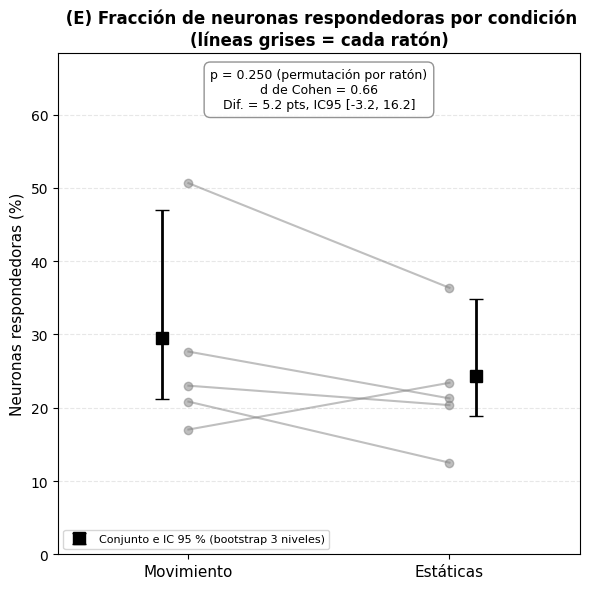

Movimiento: 91 de 308 neuronas responden (29.5 %) · ventana 2.0 s · 0 sin varianza basal (fuera del enjambre)
Estáticas: 75 de 308 neuronas responden (24.4 %) · ventana 0.25 s · 3 sin varianza basal (fuera del enjambre)


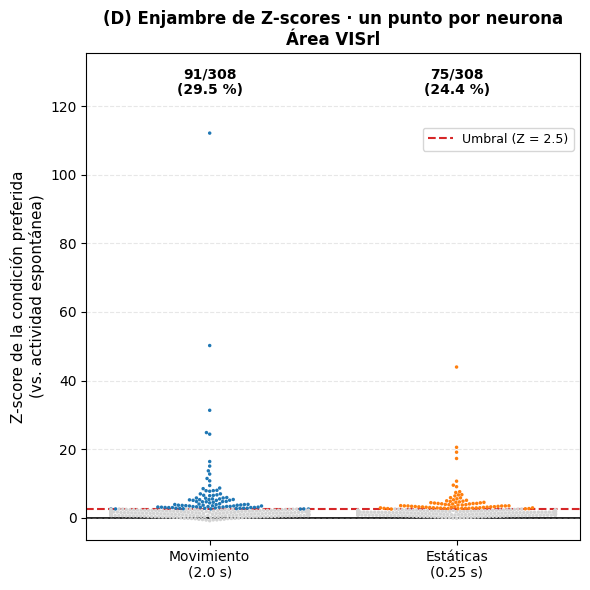

In [18]:
#Panel E y D

"""
Figura 2 · Panel E  —  Fracción de neuronas respondedoras en dos condiciones
con BOOTSTRAP JERÁRQUICO DE TRES NIVELES (ratones -> neuronas -> ensayos).

Qué corrige respecto a `graficar_fracciones_pareadas`:
  * Antes: solo se remuestreaban ratones y neuronas. La clasificación "responde / no responde"
    se calculaba UNA vez, así que los ensayos nunca se remuestreaban (faltaba el nivel 3).
  * Ahora: en cada réplica se sortean ratones, luego neuronas dentro de cada ratón, luego
    ensayos dentro de cada neurona, y se RECALCULA el Z-score y la decisión Z >= umbral.

Decisiones metodológicas (decirlas en Métodos):
  * Condición preferida: para cada neurona se fija con los datos originales (combinación de
    características con mayor tasa media) y en cada réplica se remuestrean los ensayos de ESA
    combinación. Así el IC queda centrado en la fracción observada.
  * La línea de base se remuestrea también (ensayos espontáneos del mismo ratón).
  * Estadístico: fracción de neuronas respondedoras del conjunto (n_resp / n_total).
  * Valor p y d de Cohen: unidad = ratón (n = 5), prueba de permutación exacta por cambio de
    signo de la diferencia pareada. Con 5 ratones hay 2^5 = 32 signos, así que el p bilateral
    mínimo posible es 2/32 = 0,0625.
"""
import itertools
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


# --------------------------------------------------------------------------------------
# 1. Tasas de disparo por neurona y ensayo (Hz) en una ventana [0, ventana)
# --------------------------------------------------------------------------------------
def _tasas(d, ventana):
    n_neu, n_ens = len(d["u_id"]), len(d["e_clase"])
    s_unidad = d["s_unidad"].astype(np.int64)     # POSICIÓN en las tablas u_
    s_ensayo = d["s_ensayo"].astype(np.int64)     # POSICIÓN en las tablas e_
    s_t = d["s_t"]
    en_ventana = (s_t >= 0) & (s_t < ventana)
    llave = s_unidad[en_ventana] * n_ens + s_ensayo[en_ventana]
    conteos = np.bincount(llave, minlength=n_neu * n_ens).reshape(n_neu, n_ens)
    return conteos / ventana


# --------------------------------------------------------------------------------------
# 2. Para cada neurona: tasas de sus ensayos en la condición preferida y en la basal
#    (siempre solo los ensayos de SU ratón)
# --------------------------------------------------------------------------------------
def _preparar_condicion(d, clase, ventana, caracteristicas):
    tasas = _tasas(d, ventana)
    u_raton, e_raton, e_clase = d["u_raton"], d["e_raton"], d["e_clase"]
    n_neu = len(d["u_id"])

    idx_cond = np.where(e_clase == clase)[0]
    idx_esp = np.where(e_clase == "spontaneous")[0]

    # combinaciones de características (se descartan ensayos con valores vacíos, p. ej. barridos en blanco)
    feats = np.column_stack([d[k][idx_cond].astype(float) for k in caracteristicas])
    valida = ~np.isnan(feats).any(axis=1)
    idx_cond, feats = idx_cond[valida], feats[valida]
    combos, inv = np.unique(feats, axis=0, return_inverse=True)
    inv = np.ravel(inv)

    pref, base = [], []
    for i in range(n_neu):
        mios = np.where(e_raton[idx_cond] == u_raton[i])[0]          # ensayos de mi ratón
        r = tasas[i, idx_cond[mios]]
        c = inv[mios]
        medias = np.full(len(combos), -np.inf)
        for k in np.unique(c):
            medias[k] = r[c == k].mean()
        k_pref = int(np.argmax(medias))                              # condición preferida
        pref.append(r[c == k_pref])
        base.append(tasas[i, idx_esp[e_raton[idx_esp] == u_raton[i]]])

    assert all(len(x) > 0 for x in pref), "Hay neuronas sin ensayos de esta condición: revisar u_raton / e_raton"
    assert all(len(x) > 1 for x in base), "Hay neuronas sin ensayos espontáneos suficientes"
    return _rellenar(pref), _rellenar(base)


def _rellenar(lista):
    """Lista de vectores de largo distinto -> matriz rellena con ceros + vector de largos."""
    largos = np.array([len(x) for x in lista])
    M = np.zeros((len(lista), largos.max()))
    for i, x in enumerate(lista):
        M[i, :largos[i]] = x
    return M, largos


# --------------------------------------------------------------------------------------
# 3. Decisión "responde" para un conjunto de neuronas.
#    rng=None -> datos originales.  rng=Generator -> NIVEL 3: remuestrea ensayos por neurona.
# --------------------------------------------------------------------------------------
def _responde(sel, cond, umbral, rng=None):
    (P, kP), (B, kB) = cond
    kp, kb = kP[sel], kB[sel]

    def muestrear(M, k):
        n, ancho = len(sel), M.shape[1]
        cols = np.arange(ancho)[None, :]
        mascara = cols < k[:, None]
        if rng is None:
            x = M[sel]
        else:
            idx = (rng.random((n, ancho)) * k[:, None]).astype(np.int64)   # ensayos con reemplazo
            x = np.take_along_axis(M[sel], idx, axis=1)
        return x, mascara

    xp, mp = muestrear(P, kp)
    xb, mb = muestrear(B, kb)
    mu_evo = (xp * mp).sum(1) / kp
    mu_bas = (xb * mb).sum(1) / kb
    sd_bas = np.sqrt((((xb - mu_bas[:, None]) ** 2) * mb).sum(1) / (kb - 1))
    with np.errstate(divide="ignore", invalid="ignore"):
        z = (mu_evo - mu_bas) / sd_bas
    return (sd_bas > 0) & (z >= umbral)        # sd = 0 no cuenta como respondedora (igual que en el Paso 4)


# --------------------------------------------------------------------------------------
# 4. Panel E
# --------------------------------------------------------------------------------------
def panelE_bootstrap_3niveles(d, clase_A="drifting_gratings", ventana_A=2.0,
                              feats_A=("e_orientacion", "e_frec_temporal", "e_frec_espacial"),
                              clase_B="static_gratings", ventana_B=0.25,
                              feats_B=("e_orientacion", "e_frec_espacial"),
                              nombre_A="Movimiento", nombre_B="Estáticas",
                              umbral=2.5, iteraciones=10000, semilla=0, mostrar=True,
                              archivo_png="fig2_panelE.png"):
    rng = np.random.default_rng(semilla)
    u_raton = d["u_raton"]
    ratones = np.unique(u_raton)
    neu_por_raton = {r: np.where(u_raton == r)[0] for r in ratones}
    n_neu = len(u_raton)

    cond_A = _preparar_condicion(d, clase_A, ventana_A, list(feats_A))
    cond_B = _preparar_condicion(d, clase_B, ventana_B, list(feats_B))

    # ---- observado (sin remuestrear) ----
    todas = np.arange(n_neu)
    resp_A = _responde(todas, cond_A, umbral)
    resp_B = _responde(todas, cond_B, umbral)
    obs = np.array([resp_A.mean(), resp_B.mean()])
    frac_raton = np.array([[resp_A[neu_por_raton[r]].mean(), resp_B[neu_por_raton[r]].mean()] for r in ratones])

    # ---- bootstrap jerárquico: ratones -> neuronas -> ensayos ----
    boot = np.zeros((iteraciones, 2))
    for b in range(iteraciones):
        r_boot = rng.choice(ratones, size=len(ratones), replace=True)                    # NIVEL 1
        sel = np.concatenate([rng.choice(neu_por_raton[r], size=len(neu_por_raton[r]),   # NIVEL 2
                                         replace=True) for r in r_boot])
        boot[b, 0] = _responde(sel, cond_A, umbral, rng).mean()                          # NIVEL 3 (dentro)
        boot[b, 1] = _responde(sel, cond_B, umbral, rng).mean()
    dif_boot = boot[:, 0] - boot[:, 1]
    ic = np.percentile(boot, [2.5, 97.5], axis=0)             # 2 x 2: filas = percentil, columnas = A, B
    ic_dif = np.percentile(dif_boot, [2.5, 97.5])

    # ---- comparación con el t-test que IGNORA el ratón (neuronas como observaciones independientes) ----
    dif_neu = resp_A.astype(float) - resp_B.astype(float)
    se = dif_neu.std(ddof=1) / np.sqrt(n_neu)
    tcrit = stats.t.ppf(0.975, n_neu - 1)
    ic_dif_ingenuo = (dif_neu.mean() - tcrit * se, dif_neu.mean() + tcrit * se)
    t_ing, p_ing = stats.ttest_rel(resp_A.astype(float), resp_B.astype(float))

    # ---- valor p (permutación exacta por signo, unidad = ratón) y d de Cohen pareado ----
    dif_r = frac_raton[:, 0] - frac_raton[:, 1]
    obs_dif = dif_r.mean()
    perms = np.array([(dif_r * np.array(s)).mean() for s in itertools.product([1, -1], repeat=len(dif_r))])
    p_val = np.mean(np.abs(perms) >= np.abs(obs_dif) - 1e-12)
    d_cohen = obs_dif / dif_r.std(ddof=1) if dif_r.std(ddof=1) > 0 else np.nan

    # ---- reporte en consola ----
    print(f"Umbral Z >= {umbral} · {iteraciones} réplicas · {len(ratones)} ratones · {n_neu} neuronas")
    for j, nom in enumerate([nombre_A, nombre_B]):
        print(f"{nom:>12}: {100*obs[j]:5.1f} %   IC95 jerárquico [{100*ic[0,j]:.1f}, {100*ic[1,j]:.1f}]")
    print(f"  (media de las réplicas: {100*boot[:,0].mean():.1f} % y {100*boot[:,1].mean():.1f} %)")
    for j, nom in enumerate([nombre_A, nombre_B]):
        if not (ic[0, j] <= obs[j] <= ic[1, j]):
            print(f"  AVISO: el valor observado de {nom} cae fuera de su IC. Pasa cuando muchas neuronas están justo "
                  f"bajo el umbral: al remuestrear ensayos algunas lo cruzan y la fracción de las réplicas sube. "
                  f"Hay que decirlo en Métodos/limitaciones.")
    print(f"Diferencia ({nombre_A} - {nombre_B}): {100*(obs[0]-obs[1]):.1f} puntos")
    print(f"  IC95 jerárquico (3 niveles): [{100*ic_dif[0]:.1f}, {100*ic_dif[1]:.1f}]   ancho {100*(ic_dif[1]-ic_dif[0]):.1f}")
    print(f"  IC95 t-test que ignora ratón: [{100*ic_dif_ingenuo[0]:.1f}, {100*ic_dif_ingenuo[1]:.1f}]   "
          f"ancho {100*(ic_dif_ingenuo[1]-ic_dif_ingenuo[0]):.1f}   (p = {p_ing:.2g})")
    print(f"  Permutación por ratón (exacta, 2^{len(dif_r)} signos): p = {p_val:.4f} · d de Cohen pareado = {d_cohen:.2f}")

    # ---- figura ----
    fig, ax = plt.subplots(figsize=(6, 6))
    for i in range(len(ratones)):
        ax.plot([1, 2], frac_raton[i] * 100, "o-", color="gray", alpha=0.5, lw=1.5)
    ax.errorbar([0.9, 2.1], obs * 100,
                yerr=[np.clip(obs - ic[0], 0, None) * 100, np.clip(ic[1] - obs, 0, None) * 100],
                fmt="s", color="black", markersize=8, capsize=5, lw=2,
                label="Conjunto e IC 95 % (bootstrap 3 niveles)")
    ax.set_xticks([1, 2]); ax.set_xticklabels([nombre_A, nombre_B], fontsize=11)
    ax.set_xlim(0.5, 2.5)
    ax.set_ylim(0, max(100 * ic.max(), 100 * frac_raton.max()) * 1.35)
    ax.set_ylabel("Neuronas respondedoras (%)", fontsize=11)
    ax.text(1.5, ax.get_ylim()[1] * 0.97,
            f"p = {p_val:.3f} (permutación por ratón)\nd de Cohen = {d_cohen:.2f}\n"
            f"Dif. = {100*(obs[0]-obs[1]):.1f} pts, IC95 [{100*ic_dif[0]:.1f}, {100*ic_dif[1]:.1f}]",
            ha="center", va="top", fontsize=9,
            bbox=dict(facecolor="white", alpha=0.85, edgecolor="gray", boxstyle="round,pad=0.5"))
    ax.set_title(" (E) Fracción de neuronas respondedoras por condición\n(líneas grises = cada ratón)", fontweight="bold")
    ax.grid(axis="y", alpha=0.3, ls="--"); ax.legend(loc="lower left", fontsize=8)
    plt.tight_layout()
    plt.savefig(archivo_png, dpi=200)
    if mostrar:
        plt.show()
    return dict(observado=obs, ic=ic, dif=obs[0] - obs[1], ic_dif=ic_dif, ic_dif_ingenuo=ic_dif_ingenuo,
                p=p_val, d_cohen=d_cohen, frac_raton=frac_raton, ratones=ratones)



# --------------------------------------------------------------------------------------
# 5. Panel D: enjambre del Z-score por condición  (un punto por neurona)
#    Corrige la versión anterior: el Z se calculaba promediando TODOS los ensayos de la clase
#    (se diluía la respuesta) y en estáticas se usaba mal la ventana. Ahora es el MISMO Z que
#    define "responde" en el Paso 4 y en el panel E: condición preferida de cada neurona,
#    ventana propia de cada estímulo (2 s movimiento, 0,25 s estáticas) y basal con la misma ventana.
# --------------------------------------------------------------------------------------
def _z_observado(cond):
    (P, kP), (B, kB) = cond
    mP = np.arange(P.shape[1])[None, :] < kP[:, None]
    mB = np.arange(B.shape[1])[None, :] < kB[:, None]
    mu_evo = (P * mP).sum(1) / kP
    mu_bas = (B * mB).sum(1) / kB
    sd_bas = np.sqrt((((B - mu_bas[:, None]) ** 2) * mB).sum(1) / (kB - 1))
    z = np.full(len(kP), np.nan)
    ok = sd_bas > 0
    z[ok] = (mu_evo[ok] - mu_bas[ok]) / sd_bas[ok]
    return z                                        # NaN = basal sin variabilidad (no cuenta como respondedora)


def panelD_enjambre(d, clase_A="drifting_gratings", ventana_A=2.0,
                    feats_A=("e_orientacion", "e_frec_temporal", "e_frec_espacial"),
                    clase_B="static_gratings", ventana_B=0.25,
                    feats_B=("e_orientacion", "e_frec_espacial"),
                    nombre_A="Movimiento", nombre_B="Estáticas",
                    umbral=2.5, mostrar=True, archivo_png="fig2_panelD.png"):
    import warnings
    import pandas as pd
    import seaborn as sns
    warnings.filterwarnings('ignore', message='.*cannot be placed.*')
    cond_A = _preparar_condicion(d, clase_A, ventana_A, list(feats_A))
    cond_B = _preparar_condicion(d, clase_B, ventana_B, list(feats_B))
    n_neu = len(d["u_id"])

    filas, resumen = [], []
    for nombre, ventana, cond in [(nombre_A, ventana_A, cond_A), (nombre_B, ventana_B, cond_B)]:
        z = _z_observado(cond)
        resp = np.nan_to_num(z, nan=-np.inf) >= umbral
        print(f"{nombre}: {int(resp.sum())} de {n_neu} neuronas responden ({100*resp.mean():.1f} %) · "
              f"ventana {ventana} s · {int(np.isnan(z).sum())} sin varianza basal (fuera del enjambre)")
        etiqueta = f"{nombre}\n({ventana} s)"
        for zi, ri in zip(z, resp):
            if not np.isnan(zi):
                filas.append((etiqueta, zi, f"{nombre} · responde" if ri else f"{nombre} · no responde"))
        resumen.append((etiqueta, int(resp.sum())))
    df = pd.DataFrame(filas, columns=["condicion", "z", "grupo"])

    colores = {f"{nombre_A} · responde": "tab:blue", f"{nombre_A} · no responde": "lightgray",
               f"{nombre_B} · responde": "tab:orange", f"{nombre_B} · no responde": "lightgray"}
    fig, ax = plt.subplots(figsize=(6, 6))
    try:
        sns.swarmplot(data=df, x="condicion", y="z", hue="grupo", palette=colores, dodge=False,
                      size=2.5, ax=ax, legend=False)
    except TypeError:                                   # seaborn viejo, sin el argumento legend
        sns.swarmplot(data=df, x="condicion", y="z", hue="grupo", palette=colores, dodge=False, size=2.5, ax=ax)
        if ax.get_legend() is not None:
            ax.get_legend().remove()
    ax.axhline(0, color="black", lw=1.2, zorder=0)
    ax.axhline(umbral, color="tab:red", ls="--", lw=1.5, zorder=0, label=f"Umbral (Z = {umbral})")
    ax.set_ylim(top=ax.get_ylim()[1] * 1.15)     # espacio para el conteo
    for i, (etiqueta, n_resp) in enumerate(resumen):
        ax.text(i, ax.get_ylim()[1] * 0.97, f"{n_resp}/{n_neu}\n({100*n_resp/n_neu:.1f} %)",
                ha="center", va="top", fontsize=10, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Z-score de la condición preferida\n(vs. actividad espontánea)", fontsize=11)
    ax.set_title(f"(D) Enjambre de Z-scores · un punto por neurona\nÁrea {str(d['area']) if 'area' in d.files else ''}",
                 fontweight="bold", fontsize=12)
    ax.legend(loc="upper right", fontsize=9, bbox_to_anchor=(1.0, 0.86))
    ax.grid(axis="y", alpha=0.3, ls="--")
    plt.tight_layout()
    plt.savefig(archivo_png, dpi=200)
    if mostrar:
        plt.show()


# ---- Ejecutar (para la pareja 3, VISrl: movimiento vs estáticas) ----
resultado = panelE_bootstrap_3niveles(d)
panelD_enjambre(d)


In [19]:
#verificacion para esas tres nueronas sin varianza basal

(P, kP), (B, kB) = _preparar_condicion(d, "static_gratings", 0.25, ["e_orientacion", "e_frec_espacial"])
z = _z_observado(((P, kP), (B, kB)))
idx = np.where(np.isnan(z))[0]
for i in idx:
    print("neurona", i, "· tasa evocada:", P[i, :kP[i]].mean(), "Hz · PAs basales totales:", B[i, :kB[i]].sum())

neurona 49 · tasa evocada: 1.0 Hz · PAs basales totales: 0.0
neurona 88 · tasa evocada: 2.0 Hz · PAs basales totales: 0.0
neurona 113 · tasa evocada: 6.222222222222222 Hz · PAs basales totales: 0.0


Umbral Z >= 2.5 · 10000 réplicas · 5 ratones · 308 neuronas
  Movimiento:  29.5 %   IC95 jerárquico [21.2, 47.0]
   Estáticas:   4.9 %   IC95 jerárquico [2.1, 9.9]
  (media de las réplicas: 32.4 % y 5.5 %)
Diferencia (Movimiento - Estáticas): 24.7 puntos
  IC95 jerárquico (3 niveles): [17.8, 38.5]   ancho 20.7
  IC95 t-test que ignora ratón: [19.7, 29.7]   ancho 10.0   (p = 1.5e-19)
  Permutación por ratón (exacta, 2^5 signos): p = 0.0625 · d de Cohen pareado = 2.28


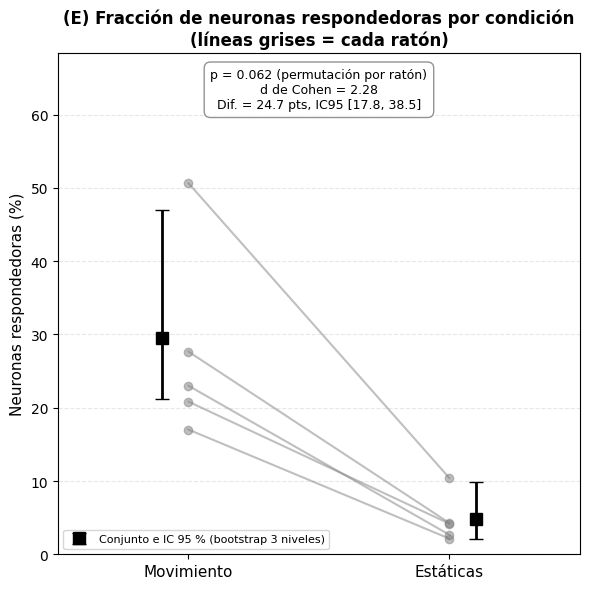

Movimiento: 91 de 308 neuronas responden (29.5 %) · ventana 2.0 s · 0 sin varianza basal (fuera del enjambre)
Estáticas: 15 de 308 neuronas responden (4.9 %) · ventana 2.0 s · 0 sin varianza basal (fuera del enjambre)


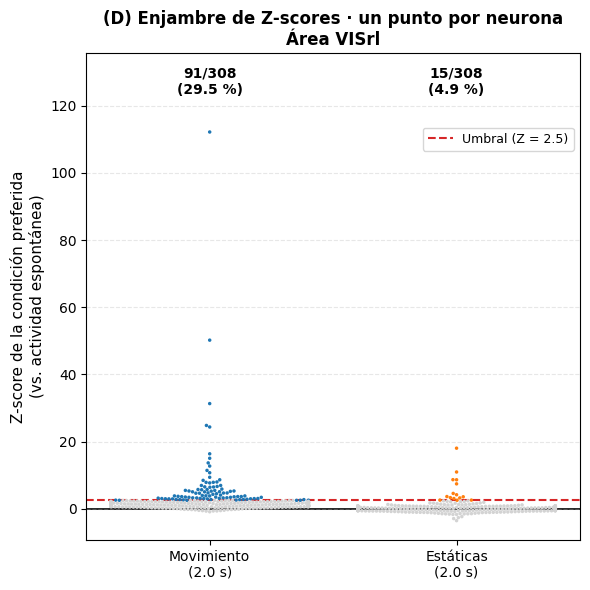

In [20]:
#prueba para saber que pasa si se toma la duracion del estimulo en 2 segundas para ambas condicione

"""
Figura 2 · Panel E  —  Fracción de neuronas respondedoras en dos condiciones
con BOOTSTRAP JERÁRQUICO DE TRES NIVELES (ratones -> neuronas -> ensayos).

Qué corrige respecto a `graficar_fracciones_pareadas`:
  * Antes: solo se remuestreaban ratones y neuronas. La clasificación "responde / no responde"
    se calculaba UNA vez, así que los ensayos nunca se remuestreaban (faltaba el nivel 3).
  * Ahora: en cada réplica se sortean ratones, luego neuronas dentro de cada ratón, luego
    ensayos dentro de cada neurona, y se RECALCULA el Z-score y la decisión Z >= umbral.

Decisiones metodológicas (decirlas en Métodos):
  * Condición preferida: para cada neurona se fija con los datos originales (combinación de
    características con mayor tasa media) y en cada réplica se remuestrean los ensayos de ESA
    combinación. Así el IC queda centrado en la fracción observada.
  * La línea de base se remuestrea también (ensayos espontáneos del mismo ratón).
  * Estadístico: fracción de neuronas respondedoras del conjunto (n_resp / n_total).
  * Valor p y d de Cohen: unidad = ratón (n = 5), prueba de permutación exacta por cambio de
    signo de la diferencia pareada. Con 5 ratones hay 2^5 = 32 signos, así que el p bilateral
    mínimo posible es 2/32 = 0,0625.
"""
import itertools
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


# --------------------------------------------------------------------------------------
# 1. Tasas de disparo por neurona y ensayo (Hz) en una ventana [0, ventana)
# --------------------------------------------------------------------------------------
def _tasas(d, ventana):
    n_neu, n_ens = len(d["u_id"]), len(d["e_clase"])
    s_unidad = d["s_unidad"].astype(np.int64)     # POSICIÓN en las tablas u_
    s_ensayo = d["s_ensayo"].astype(np.int64)     # POSICIÓN en las tablas e_
    s_t = d["s_t"]
    en_ventana = (s_t >= 0) & (s_t < ventana)
    llave = s_unidad[en_ventana] * n_ens + s_ensayo[en_ventana]
    conteos = np.bincount(llave, minlength=n_neu * n_ens).reshape(n_neu, n_ens)
    return conteos / ventana


# --------------------------------------------------------------------------------------
# 2. Para cada neurona: tasas de sus ensayos en la condición preferida y en la basal
#    (siempre solo los ensayos de SU ratón)
# --------------------------------------------------------------------------------------
def _preparar_condicion(d, clase, ventana, caracteristicas):
    tasas = _tasas(d, ventana)
    u_raton, e_raton, e_clase = d["u_raton"], d["e_raton"], d["e_clase"]
    n_neu = len(d["u_id"])

    idx_cond = np.where(e_clase == clase)[0]
    idx_esp = np.where(e_clase == "spontaneous")[0]

    # combinaciones de características (se descartan ensayos con valores vacíos, p. ej. barridos en blanco)
    feats = np.column_stack([d[k][idx_cond].astype(float) for k in caracteristicas])
    valida = ~np.isnan(feats).any(axis=1)
    idx_cond, feats = idx_cond[valida], feats[valida]
    combos, inv = np.unique(feats, axis=0, return_inverse=True)
    inv = np.ravel(inv)

    pref, base = [], []
    for i in range(n_neu):
        mios = np.where(e_raton[idx_cond] == u_raton[i])[0]          # ensayos de mi ratón
        r = tasas[i, idx_cond[mios]]
        c = inv[mios]
        medias = np.full(len(combos), -np.inf)
        for k in np.unique(c):
            medias[k] = r[c == k].mean()
        k_pref = int(np.argmax(medias))                              # condición preferida
        pref.append(r[c == k_pref])
        base.append(tasas[i, idx_esp[e_raton[idx_esp] == u_raton[i]]])

    assert all(len(x) > 0 for x in pref), "Hay neuronas sin ensayos de esta condición: revisar u_raton / e_raton"
    assert all(len(x) > 1 for x in base), "Hay neuronas sin ensayos espontáneos suficientes"
    return _rellenar(pref), _rellenar(base)


def _rellenar(lista):
    """Lista de vectores de largo distinto -> matriz rellena con ceros + vector de largos."""
    largos = np.array([len(x) for x in lista])
    M = np.zeros((len(lista), largos.max()))
    for i, x in enumerate(lista):
        M[i, :largos[i]] = x
    return M, largos


# --------------------------------------------------------------------------------------
# 3. Decisión "responde" para un conjunto de neuronas.
#    rng=None -> datos originales.  rng=Generator -> NIVEL 3: remuestrea ensayos por neurona.
# --------------------------------------------------------------------------------------
def _responde(sel, cond, umbral, rng=None):
    (P, kP), (B, kB) = cond
    kp, kb = kP[sel], kB[sel]

    def muestrear(M, k):
        n, ancho = len(sel), M.shape[1]
        cols = np.arange(ancho)[None, :]
        mascara = cols < k[:, None]
        if rng is None:
            x = M[sel]
        else:
            idx = (rng.random((n, ancho)) * k[:, None]).astype(np.int64)   # ensayos con reemplazo
            x = np.take_along_axis(M[sel], idx, axis=1)
        return x, mascara

    xp, mp = muestrear(P, kp)
    xb, mb = muestrear(B, kb)
    mu_evo = (xp * mp).sum(1) / kp
    mu_bas = (xb * mb).sum(1) / kb
    sd_bas = np.sqrt((((xb - mu_bas[:, None]) ** 2) * mb).sum(1) / (kb - 1))
    with np.errstate(divide="ignore", invalid="ignore"):
        z = (mu_evo - mu_bas) / sd_bas
    return (sd_bas > 0) & (z >= umbral)        # sd = 0 no cuenta como respondedora (igual que en el Paso 4)


# --------------------------------------------------------------------------------------
# 4. Panel E
# --------------------------------------------------------------------------------------
def panelE_bootstrap_3niveles(d, clase_A="drifting_gratings", ventana_A=2.0,
                              feats_A=("e_orientacion", "e_frec_temporal", "e_frec_espacial"),
                              clase_B="static_gratings", ventana_B=2.0,
                              feats_B=("e_orientacion", "e_frec_espacial"),
                              nombre_A="Movimiento", nombre_B="Estáticas",
                              umbral=2.5, iteraciones=10000, semilla=0, mostrar=True,
                              archivo_png="fig2_panelE.png"):
    rng = np.random.default_rng(semilla)
    u_raton = d["u_raton"]
    ratones = np.unique(u_raton)
    neu_por_raton = {r: np.where(u_raton == r)[0] for r in ratones}
    n_neu = len(u_raton)

    cond_A = _preparar_condicion(d, clase_A, ventana_A, list(feats_A))
    cond_B = _preparar_condicion(d, clase_B, ventana_B, list(feats_B))

    # ---- observado (sin remuestrear) ----
    todas = np.arange(n_neu)
    resp_A = _responde(todas, cond_A, umbral)
    resp_B = _responde(todas, cond_B, umbral)
    obs = np.array([resp_A.mean(), resp_B.mean()])
    frac_raton = np.array([[resp_A[neu_por_raton[r]].mean(), resp_B[neu_por_raton[r]].mean()] for r in ratones])

    # ---- bootstrap jerárquico: ratones -> neuronas -> ensayos ----
    boot = np.zeros((iteraciones, 2))
    for b in range(iteraciones):
        r_boot = rng.choice(ratones, size=len(ratones), replace=True)                    # NIVEL 1
        sel = np.concatenate([rng.choice(neu_por_raton[r], size=len(neu_por_raton[r]),   # NIVEL 2
                                         replace=True) for r in r_boot])
        boot[b, 0] = _responde(sel, cond_A, umbral, rng).mean()                          # NIVEL 3 (dentro)
        boot[b, 1] = _responde(sel, cond_B, umbral, rng).mean()
    dif_boot = boot[:, 0] - boot[:, 1]
    ic = np.percentile(boot, [2.5, 97.5], axis=0)             # 2 x 2: filas = percentil, columnas = A, B
    ic_dif = np.percentile(dif_boot, [2.5, 97.5])

    # ---- comparación con el t-test que IGNORA el ratón (neuronas como observaciones independientes) ----
    dif_neu = resp_A.astype(float) - resp_B.astype(float)
    se = dif_neu.std(ddof=1) / np.sqrt(n_neu)
    tcrit = stats.t.ppf(0.975, n_neu - 1)
    ic_dif_ingenuo = (dif_neu.mean() - tcrit * se, dif_neu.mean() + tcrit * se)
    t_ing, p_ing = stats.ttest_rel(resp_A.astype(float), resp_B.astype(float))

    # ---- valor p (permutación exacta por signo, unidad = ratón) y d de Cohen pareado ----
    dif_r = frac_raton[:, 0] - frac_raton[:, 1]
    obs_dif = dif_r.mean()
    perms = np.array([(dif_r * np.array(s)).mean() for s in itertools.product([1, -1], repeat=len(dif_r))])
    p_val = np.mean(np.abs(perms) >= np.abs(obs_dif) - 1e-12)
    d_cohen = obs_dif / dif_r.std(ddof=1) if dif_r.std(ddof=1) > 0 else np.nan

    # ---- reporte en consola ----
    print(f"Umbral Z >= {umbral} · {iteraciones} réplicas · {len(ratones)} ratones · {n_neu} neuronas")
    for j, nom in enumerate([nombre_A, nombre_B]):
        print(f"{nom:>12}: {100*obs[j]:5.1f} %   IC95 jerárquico [{100*ic[0,j]:.1f}, {100*ic[1,j]:.1f}]")
    print(f"  (media de las réplicas: {100*boot[:,0].mean():.1f} % y {100*boot[:,1].mean():.1f} %)")
    for j, nom in enumerate([nombre_A, nombre_B]):
        if not (ic[0, j] <= obs[j] <= ic[1, j]):
            print(f"  AVISO: el valor observado de {nom} cae fuera de su IC. Pasa cuando muchas neuronas están justo "
                  f"bajo el umbral: al remuestrear ensayos algunas lo cruzan y la fracción de las réplicas sube. "
                  f"Hay que decirlo en Métodos/limitaciones.")
    print(f"Diferencia ({nombre_A} - {nombre_B}): {100*(obs[0]-obs[1]):.1f} puntos")
    print(f"  IC95 jerárquico (3 niveles): [{100*ic_dif[0]:.1f}, {100*ic_dif[1]:.1f}]   ancho {100*(ic_dif[1]-ic_dif[0]):.1f}")
    print(f"  IC95 t-test que ignora ratón: [{100*ic_dif_ingenuo[0]:.1f}, {100*ic_dif_ingenuo[1]:.1f}]   "
          f"ancho {100*(ic_dif_ingenuo[1]-ic_dif_ingenuo[0]):.1f}   (p = {p_ing:.2g})")
    print(f"  Permutación por ratón (exacta, 2^{len(dif_r)} signos): p = {p_val:.4f} · d de Cohen pareado = {d_cohen:.2f}")

    # ---- figura ----
    fig, ax = plt.subplots(figsize=(6, 6))
    for i in range(len(ratones)):
        ax.plot([1, 2], frac_raton[i] * 100, "o-", color="gray", alpha=0.5, lw=1.5)
    ax.errorbar([0.9, 2.1], obs * 100,
                yerr=[np.clip(obs - ic[0], 0, None) * 100, np.clip(ic[1] - obs, 0, None) * 100],
                fmt="s", color="black", markersize=8, capsize=5, lw=2,
                label="Conjunto e IC 95 % (bootstrap 3 niveles)")
    ax.set_xticks([1, 2]); ax.set_xticklabels([nombre_A, nombre_B], fontsize=11)
    ax.set_xlim(0.5, 2.5)
    ax.set_ylim(0, max(100 * ic.max(), 100 * frac_raton.max()) * 1.35)
    ax.set_ylabel("Neuronas respondedoras (%)", fontsize=11)
    ax.text(1.5, ax.get_ylim()[1] * 0.97,
            f"p = {p_val:.3f} (permutación por ratón)\nd de Cohen = {d_cohen:.2f}\n"
            f"Dif. = {100*(obs[0]-obs[1]):.1f} pts, IC95 [{100*ic_dif[0]:.1f}, {100*ic_dif[1]:.1f}]",
            ha="center", va="top", fontsize=9,
            bbox=dict(facecolor="white", alpha=0.85, edgecolor="gray", boxstyle="round,pad=0.5"))
    ax.set_title("(E) Fracción de neuronas respondedoras por condición\n(líneas grises = cada ratón)", fontweight="bold")
    ax.grid(axis="y", alpha=0.3, ls="--"); ax.legend(loc="lower left", fontsize=8)
    plt.tight_layout()
    plt.savefig(archivo_png, dpi=200)
    if mostrar:
        plt.show()
    return dict(observado=obs, ic=ic, dif=obs[0] - obs[1], ic_dif=ic_dif, ic_dif_ingenuo=ic_dif_ingenuo,
                p=p_val, d_cohen=d_cohen, frac_raton=frac_raton, ratones=ratones)



# --------------------------------------------------------------------------------------
# 5. Panel D: enjambre del Z-score por condición  (un punto por neurona)
#    Corrige la versión anterior: el Z se calculaba promediando TODOS los ensayos de la clase
#    (se diluía la respuesta) y en estáticas se usaba mal la ventana. Ahora es el MISMO Z que
#    define "responde" en el Paso 4 y en el panel E: condición preferida de cada neurona,
#    ventana propia de cada estímulo (2 s movimiento, 0,25 s estáticas) y basal con la misma ventana.
# --------------------------------------------------------------------------------------
def _z_observado(cond):
    (P, kP), (B, kB) = cond
    mP = np.arange(P.shape[1])[None, :] < kP[:, None]
    mB = np.arange(B.shape[1])[None, :] < kB[:, None]
    mu_evo = (P * mP).sum(1) / kP
    mu_bas = (B * mB).sum(1) / kB
    sd_bas = np.sqrt((((B - mu_bas[:, None]) ** 2) * mB).sum(1) / (kB - 1))
    z = np.full(len(kP), np.nan)
    ok = sd_bas > 0
    z[ok] = (mu_evo[ok] - mu_bas[ok]) / sd_bas[ok]
    return z                                        # NaN = basal sin variabilidad (no cuenta como respondedora)


def panelD_enjambre(d, clase_A="drifting_gratings", ventana_A=2.0,
                    feats_A=("e_orientacion", "e_frec_temporal", "e_frec_espacial"),
                    clase_B="static_gratings", ventana_B=2.0,
                    feats_B=("e_orientacion", "e_frec_espacial"),
                    nombre_A="Movimiento", nombre_B="Estáticas",
                    umbral=2.5, mostrar=True, archivo_png="fig2_panelD.png"):
    import warnings
    import pandas as pd
    import seaborn as sns
    warnings.filterwarnings('ignore', message='.*cannot be placed.*')
    cond_A = _preparar_condicion(d, clase_A, ventana_A, list(feats_A))
    cond_B = _preparar_condicion(d, clase_B, ventana_B, list(feats_B))
    n_neu = len(d["u_id"])

    filas, resumen = [], []
    for nombre, ventana, cond in [(nombre_A, ventana_A, cond_A), (nombre_B, ventana_B, cond_B)]:
        z = _z_observado(cond)
        resp = np.nan_to_num(z, nan=-np.inf) >= umbral
        print(f"{nombre}: {int(resp.sum())} de {n_neu} neuronas responden ({100*resp.mean():.1f} %) · "
              f"ventana {ventana} s · {int(np.isnan(z).sum())} sin varianza basal (fuera del enjambre)")
        etiqueta = f"{nombre}\n({ventana} s)"
        for zi, ri in zip(z, resp):
            if not np.isnan(zi):
                filas.append((etiqueta, zi, f"{nombre} · responde" if ri else f"{nombre} · no responde"))
        resumen.append((etiqueta, int(resp.sum())))
    df = pd.DataFrame(filas, columns=["condicion", "z", "grupo"])

    colores = {f"{nombre_A} · responde": "tab:blue", f"{nombre_A} · no responde": "lightgray",
               f"{nombre_B} · responde": "tab:orange", f"{nombre_B} · no responde": "lightgray"}
    fig, ax = plt.subplots(figsize=(6, 6))
    try:
        sns.swarmplot(data=df, x="condicion", y="z", hue="grupo", palette=colores, dodge=False,
                      size=2.5, ax=ax, legend=False)
    except TypeError:                                   # seaborn viejo, sin el argumento legend
        sns.swarmplot(data=df, x="condicion", y="z", hue="grupo", palette=colores, dodge=False, size=2.5, ax=ax)
        if ax.get_legend() is not None:
            ax.get_legend().remove()
    ax.axhline(0, color="black", lw=1.2, zorder=0)
    ax.axhline(umbral, color="tab:red", ls="--", lw=1.5, zorder=0, label=f"Umbral (Z = {umbral})")
    ax.set_ylim(top=ax.get_ylim()[1] * 1.15)     # espacio para el conteo
    for i, (etiqueta, n_resp) in enumerate(resumen):
        ax.text(i, ax.get_ylim()[1] * 0.97, f"{n_resp}/{n_neu}\n({100*n_resp/n_neu:.1f} %)",
                ha="center", va="top", fontsize=10, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Z-score de la condición preferida\n(vs. actividad espontánea)", fontsize=11)
    ax.set_title(f"(D) Enjambre de Z-scores · un punto por neurona\nÁrea {str(d['area']) if 'area' in d.files else ''}",
                 fontweight="bold", fontsize=12)
    ax.legend(loc="upper right", fontsize=9, bbox_to_anchor=(1.0, 0.86))
    ax.grid(axis="y", alpha=0.3, ls="--")
    plt.tight_layout()
    plt.savefig(archivo_png, dpi=200)
    if mostrar:
        plt.show()


# ---- Ejecutar (para la pareja 3, VISrl: movimiento vs estáticas) ----
resultado = panelE_bootstrap_3niveles(d)
panelD_enjambre(d)

El efecto de la promediación (Dilución): En este código, calculamos el Z-score promediando la respuesta de la neurona frente a todos los ensayos de la clase. Si una neurona está altamente especializada y solo dispara de forma extrema ante una rejilla que se mueve a 90° con una frecuencia específica, esa ráfaga de actividad se diluye masivamente al promediarla con las docenas de ensayos de otras orientaciones donde la neurona no hizo nada.

Codificación dispersa (Sparse coding): El área VISrl (corteza visual rostrolateral) es un área visual superior. A diferencia de la corteza visual primaria (V1), las neuronas en VISrl suelen preferir estímulos mucho más complejos (como escenas naturales, objetos que se acercan o velocidades específicas) en lugar de rejillas simples. Es natural que muchas ignoren por completo estos estímulos básicos.

Registros de alta densidad: Las sondas modernas registran indiscriminadamente toda la actividad eléctrica en su trayectoria. En cualquier experimento in vivo, es estándar que solo una fracción minoritaria de las unidades capturadas (a menudo entre el 10% y el 30%) esté modulada directamente por la tarea visual actual, mientras que el resto mantiene su actividad basal relacionada con el estado interno del animal.

In [21]:
#Pruebas

In [22]:
print(np.unique(d["e_dur"][d["e_clase"] == "static_gratings"]))
m = d["e_clase"][d["s_ensayo"]] == "static_gratings"
print(d["s_t"][m].max())
for v in (2.0, 0.25):
       z = _z_observado(_preparar_condicion(d, "static_gratings", v, ["e_orientacion", "e_frec_espacial"]))
       print("ventana", v, "-> respondedoras:", int(np.nansum(z >= 2.5)))

[0.25019327 0.25019386 0.25019425 0.25019494 0.25019577 0.25019613
 0.25019637 0.25019673 0.25019675 0.25019744 0.25019756 0.25019825
 0.25019863 0.25019887 0.25019923 0.25019926 0.25019994 0.25020006
 0.25020075 0.25020078 0.25020114 0.25020137 0.25020173 0.25020176
 0.25020245 0.25020257 0.25020325 0.25020328 0.25020364 0.25020385
 0.25020424 0.25020427 0.25020495 0.25020507 0.25020576 0.25020614
 0.25020635 0.25020674 0.25020677 0.25020745 0.25020757 0.25020823
 0.25020826 0.25020865 0.25020885 0.25020924 0.25020927 0.25020993
 0.25021005 0.25021073 0.25021076 0.25021115 0.25021136 0.25021175
 0.25021243 0.25021255 0.25021324 0.25021327 0.25021365 0.25021386
 0.25021422 0.25021425 0.25021493 0.25021505 0.25021574 0.25021577
 0.25021613 0.25021636 0.25021672 0.25021675 0.25021744 0.25021756
 0.25021824 0.25021827 0.25021863 0.25021887 0.25021926 0.25021994
 0.25022006 0.25022075 0.25022078 0.25022113 0.25022137 0.25022173
 0.25022176 0.25022256 0.25022328 0.25022364 0.25022385 0.2502

In [23]:
for clase in np.unique(d["e_clase"]):
       m = d["e_clase"] == clase
       print(clase, np.unique(np.round(d["e_dur"][m], 3)))

drifting_gratings [2.002]
flashes [0.25]
natural_movie_one [30.025]
natural_scenes [0.25]
spontaneous [2.]
static_gratings [0.25]


In [24]:
clase_de_cada_pa = d["e_clase"][d["s_ensayo"]]
for clase in np.unique(d["e_clase"]):
       t = d["s_t"][clase_de_cada_pa == clase]
       print(clase, "s_t de", round(t.min(), 3), "a", round(t.max(), 3))

drifting_gratings s_t de -0.5 a 2.502
flashes s_t de -0.5 a 1.25
natural_movie_one s_t de -1.0 a 31.025
natural_scenes s_t de -0.3 a 0.75
spontaneous s_t de 0.0 a 2.0
static_gratings s_t de -0.3 a 0.75


In [25]:
print(d.files)

['area', 'fuente', 'filtro', 'u_id', 'u_raton', 'u_canal', 'u_profundidad', 'u_snr', 'u_amplitude_cutoff', 'u_presence_ratio', 'u_isi_violations', 'u_firing_rate', 'u_onda', 'e_clase', 'e_raton', 'e_t0', 'e_dur', 'e_orientacion', 'e_frec_temporal', 'e_frec_espacial', 'e_contraste', 'e_color', 'e_imagen', 's_unidad', 's_ensayo', 's_t']



=== Movimiento  (ventana 2.0 s, 308 neuronas) ===
 Umbral | Respondedoras | Fracción | Falsos positivos esperados | Proporción de falsos
    2.0 |           126 |    40.9% |   2.6% (~ 7.9 neuronas)      |                  6%
    2.5 |            91 |    29.5% |   1.3% (~ 3.9 neuronas)      |                  4%
    3.0 |            71 |    23.1% |   0.7% (~ 2.1 neuronas)      |                  3%
    3.5 |            55 |    17.9% |   0.4% (~ 1.2 neuronas)      |                  2%
    4.0 |            45 |    14.6% |   0.2% (~ 0.7 neuronas)      |                  2%

=== Estáticas  (ventana 0.25 s, 308 neuronas) ===
 Umbral | Respondedoras | Fracción | Falsos positivos esperados | Proporción de falsos
    2.0 |           107 |    34.7% |   4.9% (~15.1 neuronas)      |                 14%
    2.5 |            75 |    24.4% |   2.4% (~ 7.3 neuronas)      |                 10%
    3.0 |            54 |    17.5% |   1.4% (~ 4.5 neuronas)      |                  8%
    3.5 |           

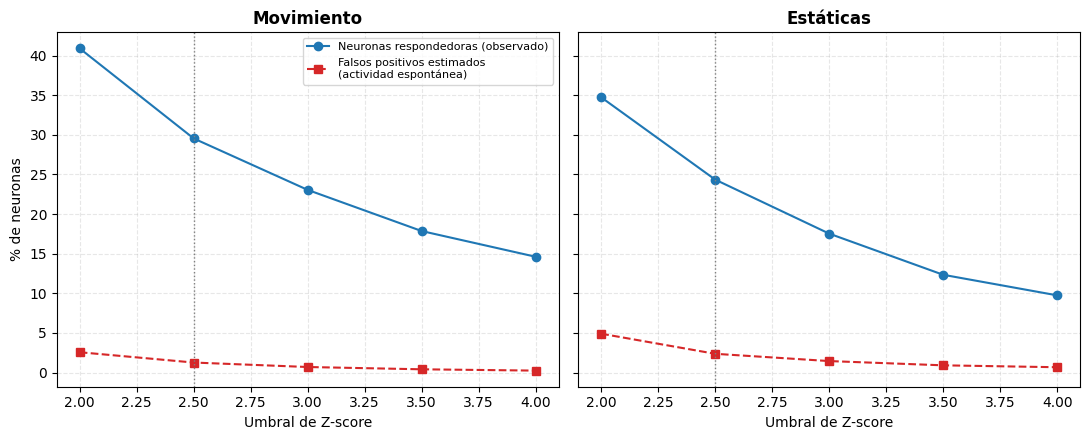


Lectura: 'Proporción de falsos' = falsos positivos esperados / respondedoras observadas.
Nota: la línea de base del nulo usa la mitad de los ensayos espontáneos, así que el nulo es algo más ruidoso que el análisis real (estimación conservadora).


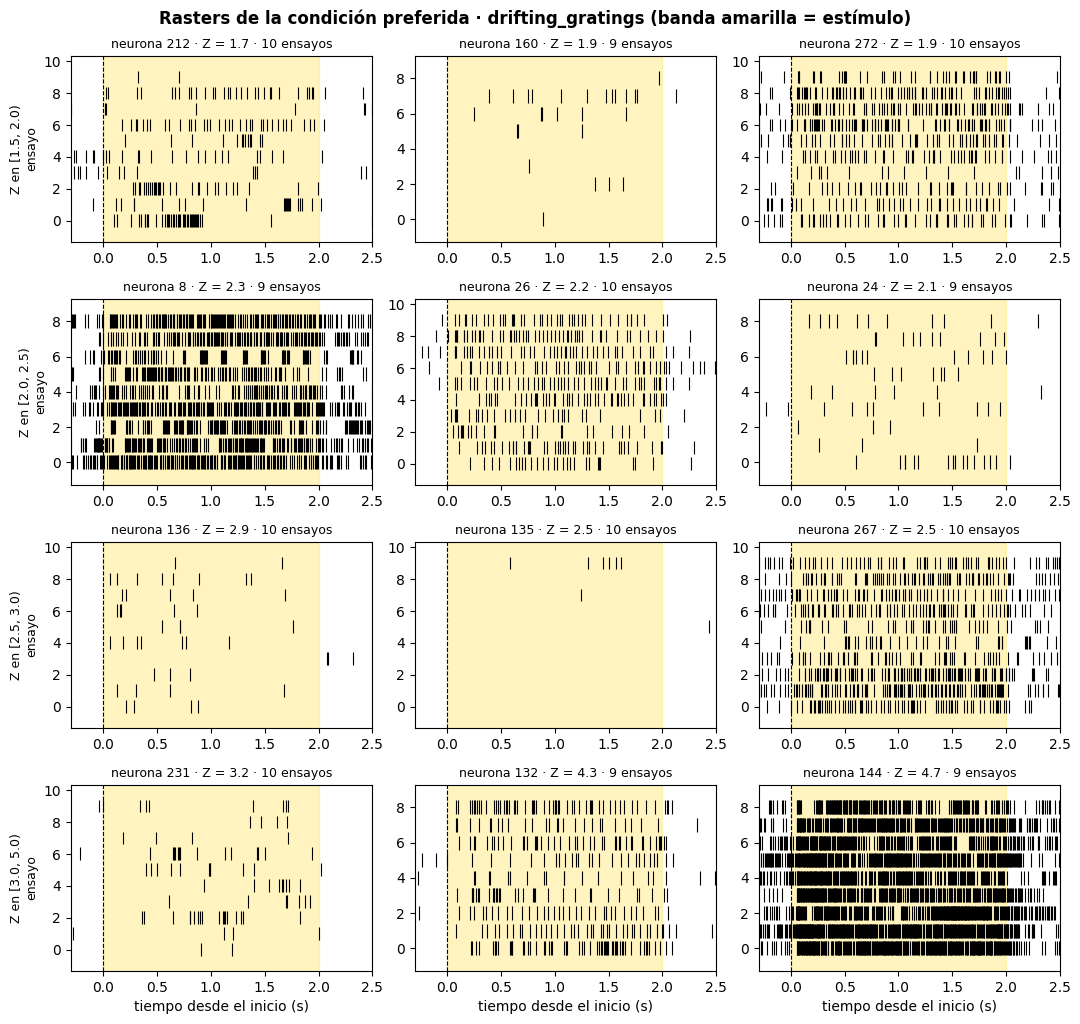

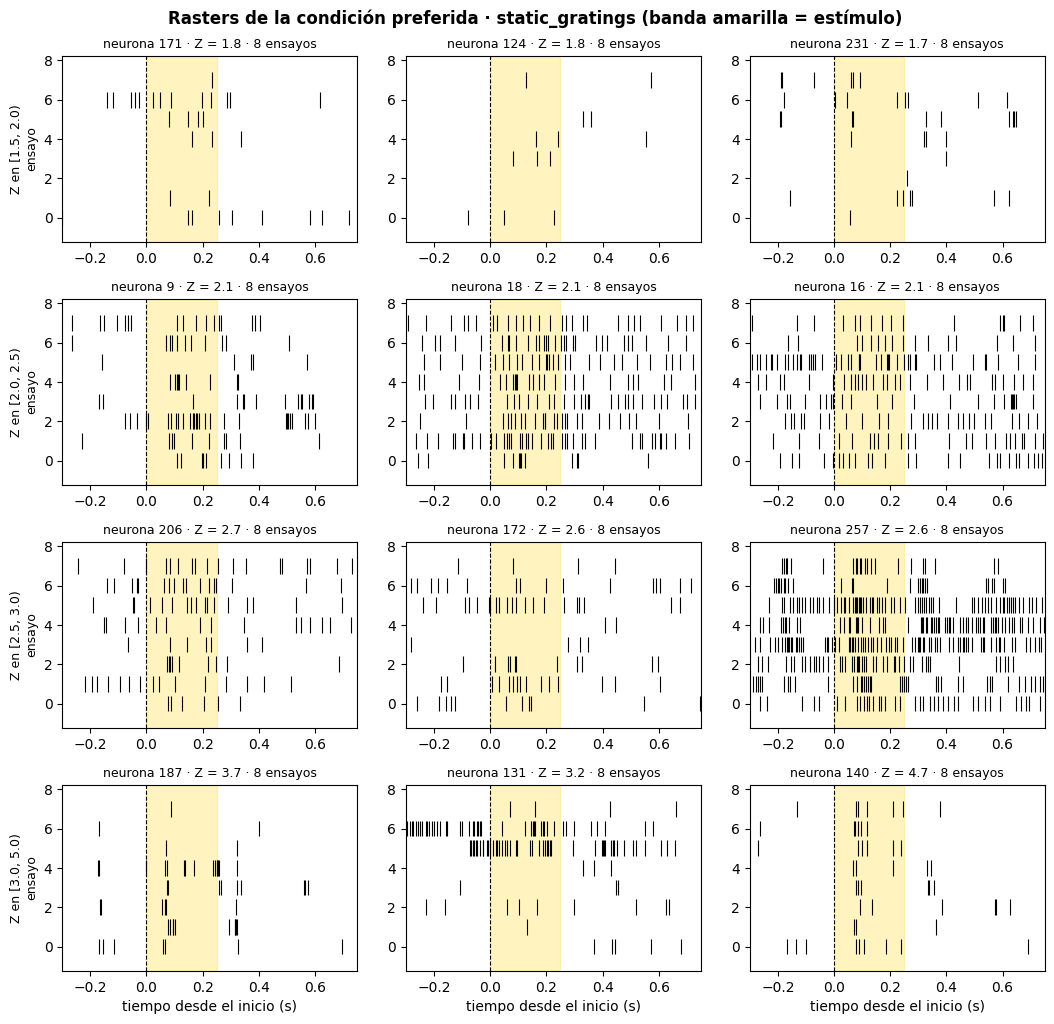

In [26]:

# -*- coding: utf-8 -*-
"""
Cómo justificar el umbral de Z-score (Z >= 2,5)  ·  Proyecto final
------------------------------------------------------------------
IMPORTANTE: pegar en una celda NUEVA, DESPUÉS de haber corrido la celda con el código del
panel E / panel D (este código reutiliza sus funciones auxiliares: _tasas,
_preparar_condicion y _z_observado).

Tres evidencias para la sección de Métodos:
  1. tabla_sensibilidad  : fracción de respondedoras con Z >= 2, 2,5, 3, 3,5, 4  (¿cambia la conclusión?)
  2. tasa de falsos positivos estimada con la actividad ESPONTÁNEA de las propias neuronas
     (se incluye el efecto de escoger la mejor combinación de cada neurona)
  3. galeria_rasters     : rasters de neuronas justo por debajo / por encima del umbral, para juzgar a ojo

Uso rápido:
    resultado_umbral = justificar_umbral(d)
    galeria_rasters(d)                                         # movimiento
    galeria_rasters(d, clase="static_gratings", ventana=0.25,
                    feats=("e_orientacion", "e_frec_espacial"),
                    rangos_z=((1.5, 2.0), (2.0, 2.5), (2.5, 3.0), (3.0, 5.0)))
"""
import numpy as np
import matplotlib.pyplot as plt


# --------------------------------------------------------------------------------------
# Auxiliares
# --------------------------------------------------------------------------------------
def _tamanos_combos(d, clase, caracteristicas):
    """Por neurona: cuántos ensayos tiene cada combinación de características (solo su ratón)."""
    u_raton, e_raton, e_clase = d["u_raton"], d["e_raton"], d["e_clase"]
    idx = np.where(e_clase == clase)[0]
    feats = np.column_stack([d[k][idx].astype(float) for k in caracteristicas])
    ok = ~np.isnan(feats).any(axis=1)
    idx, feats = idx[ok], feats[ok]
    _, inv = np.unique(feats, axis=0, return_inverse=True)
    inv = np.ravel(inv)
    por_raton = {}
    for r in np.unique(u_raton):
        cuenta = np.bincount(inv[e_raton[idx] == r], minlength=inv.max() + 1)
        por_raton[r] = cuenta[cuenta > 0]
    return [por_raton[r] for r in u_raton]


def _z_nulo(d, clase, ventana, caracteristicas, repeticiones, semilla):
    """
    Z-scores esperados SIN estímulo real. Para cada neurona y repetición:
      - se parte al azar su actividad espontánea en dos mitades: una hace de línea de base
        y de la otra se sortean 'pseudo-ensayos' con la misma estructura que las condiciones reales
        (mismo número de combinaciones y de ensayos por combinación);
      - se toma la MEJOR pseudo-combinación (igual que con los datos reales) y se calcula su Z.
    Todo lo que pase el umbral aquí es, por construcción, un falso positivo.
    """
    rng = np.random.default_rng(semilla)
    (P, kP), (B, kB) = _preparar_condicion(d, clase, ventana, list(caracteristicas))
    tam = _tamanos_combos(d, clase, caracteristicas)
    n = len(kB)
    z = np.full((n, repeticiones), np.nan)
    for i in range(n):
        b = B[i, :kB[i]]
        mitad = len(b) // 2
        perm = np.argsort(rng.random((repeticiones, len(b))), axis=1)
        base = b[perm[:, :mitad]]                      # repeticiones x mitad
        pool = b[perm[:, mitad:]]                      # repeticiones x (len(b)-mitad)
        mu, sd = base.mean(axis=1), base.std(axis=1, ddof=1)
        s = tam[i]
        inicios = np.r_[0, np.cumsum(s)[:-1]]
        idx = (rng.random((repeticiones, s.sum())) * pool.shape[1]).astype(np.int64)
        vals = np.take_along_axis(pool, idx, axis=1)
        medias = np.add.reduceat(vals, inicios, axis=1) / s        # media de cada pseudo-combinación
        with np.errstate(divide="ignore", invalid="ignore"):
            zi = (medias.max(axis=1) - mu) / sd
        zi[sd == 0] = np.nan                                       # igual que con datos reales
        z[i] = zi
    return z


# --------------------------------------------------------------------------------------
# 1 y 2. Sensibilidad + falsos positivos estimados
# --------------------------------------------------------------------------------------
def justificar_umbral(d, umbrales=(2.0, 2.5, 3.0, 3.5, 4.0), repeticiones=200, semilla=0,
                      condiciones=None, mostrar=True, archivo_png="fig_justificacion_umbral.png"):
    if condiciones is None:
        condiciones = [
            ("Movimiento", "drifting_gratings", 2.0, ("e_orientacion", "e_frec_temporal", "e_frec_espacial")),
            ("Estáticas", "static_gratings", 0.25, ("e_orientacion", "e_frec_espacial")),
        ]
    n_neu = len(d["u_id"])
    resultados = {}
    fig, axes = plt.subplots(1, len(condiciones), figsize=(5.5 * len(condiciones), 4.5), sharey=True)
    axes = np.atleast_1d(axes)

    for ax, (nombre, clase, ventana, feats) in zip(axes, condiciones):
        z_obs = _z_observado(_preparar_condicion(d, clase, ventana, list(feats)))
        znulo = _z_nulo(d, clase, ventana, feats, repeticiones, semilla)
        filas = []
        print(f"\n=== {nombre}  (ventana {ventana} s, {n_neu} neuronas) ===")
        print(f"{'Umbral':>7} | {'Respondedoras':>13} | {'Fracción':>8} | {'Falsos positivos esperados':>26} | {'Proporción de falsos':>20}")
        for u in umbrales:
            n_obs = int(np.sum(np.nan_to_num(z_obs, nan=-np.inf) >= u))
            frac = n_obs / n_neu
            fpr = float(np.mean(np.nan_to_num(znulo, nan=-np.inf) >= u))    # por neurona
            fdr = min(1.0, fpr / frac) if frac > 0 else np.nan
            filas.append((u, n_obs, frac, fpr, fdr))
            print(f"{u:>7.1f} | {n_obs:>13d} | {100*frac:>7.1f}% | {100*fpr:>5.1f}% (~{fpr*n_neu:>4.1f} neuronas)"
                  f"      | {100*fdr:>18.0f}%")
        resultados[nombre] = dict(filas=filas, z_obs=z_obs, z_nulo=znulo)

        us = [f[0] for f in filas]
        ax.plot(us, [100 * f[2] for f in filas], "o-", color="tab:blue", label="Neuronas respondedoras (observado)")
        ax.plot(us, [100 * f[3] for f in filas], "s--", color="tab:red", label="Falsos positivos estimados\n(actividad espontánea)")
        ax.axvline(2.5, color="gray", ls=":", lw=1)
        ax.set_title(nombre, fontweight="bold")
        ax.set_xlabel("Umbral de Z-score")
        ax.grid(alpha=0.3, ls="--")
    axes[0].set_ylabel("% de neuronas")
    axes[0].legend(fontsize=8, loc="upper right")
    plt.tight_layout()
    plt.savefig(archivo_png, dpi=200)
    if mostrar:
        plt.show()
    print("\nLectura: 'Proporción de falsos' = falsos positivos esperados / respondedoras observadas.")
    print("Nota: la línea de base del nulo usa la mitad de los ensayos espontáneos, así que el nulo es algo más ruidoso que el análisis real (estimación conservadora).")
    return resultados


# --------------------------------------------------------------------------------------
# 3. Galería de rasters cerca del umbral
# --------------------------------------------------------------------------------------
def _ensayos_preferidos(d, tasas, i, clase, feats):
    e_clase, e_raton = d["e_clase"], d["e_raton"]
    idx = np.where((e_clase == clase) & (e_raton == d["u_raton"][i]))[0]
    F = np.column_stack([d[k][idx].astype(float) for k in feats])
    ok = ~np.isnan(F).any(axis=1)
    idx, F = idx[ok], F[ok]
    combos, inv = np.unique(F, axis=0, return_inverse=True)
    inv = np.ravel(inv)
    medias = np.array([tasas[i, idx[inv == k]].mean() if np.any(inv == k) else -np.inf for k in range(len(combos))])
    return idx[inv == int(np.argmax(medias))]


def galeria_rasters(d, clase="drifting_gratings", ventana=2.0,
                    feats=("e_orientacion", "e_frec_temporal", "e_frec_espacial"),
                    rangos_z=((1.5, 2.0), (2.0, 2.5), (2.5, 3.0), (3.0, 5.0)), por_rango=3,
                    semilla=0, mostrar=True, archivo_png="fig_rasters_umbral.png"):
    """Cada fila = un rango de Z; cada columna = una neurona sorteada de ese rango.
    Se dibujan los ensayos de la condición preferida de la neurona (lo que entra al Z-score)."""
    rng = np.random.default_rng(semilla)
    tasas = _tasas(d, ventana)
    z = _z_observado(_preparar_condicion(d, clase, ventana, list(feats)))
    s_unidad, s_ensayo, s_t = d["s_unidad"].astype(np.int64), d["s_ensayo"].astype(np.int64), d["s_t"]

    fig, axes = plt.subplots(len(rangos_z), por_rango, figsize=(3.6 * por_rango, 2.6 * len(rangos_z)), squeeze=False)
    for fila, (lo, hi) in enumerate(rangos_z):
        candidatas = np.where((z >= lo) & (z < hi))[0]
        elegidas = rng.choice(candidatas, size=min(por_rango, len(candidatas)), replace=False) if len(candidatas) else []
        for col in range(por_rango):
            ax = axes[fila, col]
            if col >= len(elegidas):
                ax.axis("off")
                if col == 0:
                    ax.text(0.5, 0.5, f"sin neuronas con Z en [{lo}, {hi})", ha="center", va="center", transform=ax.transAxes)
                continue
            i = int(elegidas[col])
            ens_pref = _ensayos_preferidos(d, tasas, i, clase, feats)
            mios = s_unidad == i
            t_i, e_i = s_t[mios], s_ensayo[mios]
            raster = [t_i[e_i == e] for e in ens_pref]
            ax.eventplot(raster, colors="black", linelengths=0.8, linewidths=0.8)
            ax.axvspan(0, ventana, color="gold", alpha=0.25)
            ax.axvline(0, color="k", ls="--", lw=0.8)
            ax.set_xlim(-0.3, min(ventana + 0.5, 2.5))
            ax.set_title(f"neurona {i} · Z = {z[i]:.1f} · {len(ens_pref)} ensayos", fontsize=9)
            if col == 0:
                ax.set_ylabel(f"Z en [{lo}, {hi})\nensayo", fontsize=9)
            if fila == len(rangos_z) - 1:
                ax.set_xlabel("tiempo desde el inicio (s)")
    fig.suptitle(f"Rasters de la condición preferida · {clase} (banda amarilla = estímulo)", fontweight="bold")
    plt.tight_layout()
    plt.savefig(archivo_png, dpi=200)
    if mostrar:
        plt.show()


# ---- Ejecutar ----
resultado_umbral = justificar_umbral(d)
galeria_rasters(d)
galeria_rasters(d, clase="static_gratings", ventana=0.25, feats=("e_orientacion", "e_frec_espacial"))
